<a href="https://colab.research.google.com/github/professionaltarun2004/navier-stokes-first-principles-lab/blob/main/naiver_stokes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Can We Build Navier–Stokes From Scratch?
A Computational Investigation of Fluid Motion, Vorticity, Viscosity and Concentration

In [169]:
import numpy as np
import matplotlib.pyplot as plt

# Define the grid for our 2D space
x = np.linspace(-5, 5, 15) # 15 points from -5 to 5 for x-coordinates
y = np.linspace(-5, 5, 15) # 15 points from -5 to 5 for y-coordinates
X, Y = np.meshgrid(x, y) # Create a grid of (x,y) coordinates

### Uniform Flow

A uniform flow field is one where the velocity is constant in magnitude and direction at every point in space. This represents a simple translation of the fluid without any deformation or rotation.


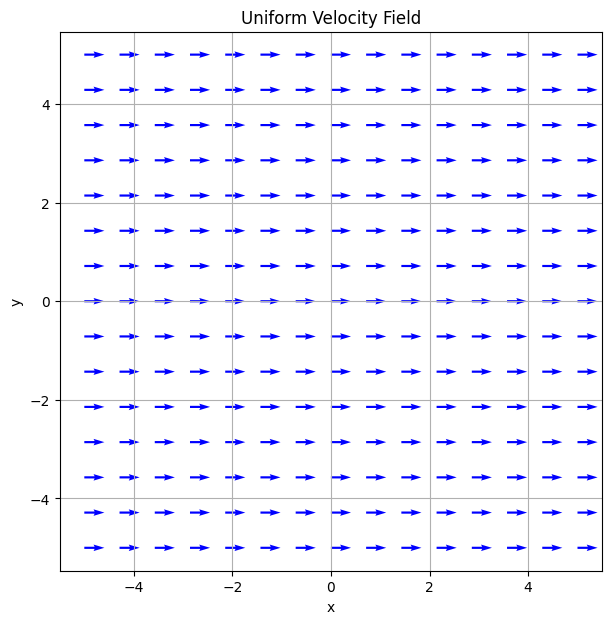

In [170]:
# Define uniform velocity components (e.g., moving purely to the right)
U_uniform = 1.0 # x-component of velocity
V_uniform = 0.0 # y-component of velocity

# Create arrays of these constant values for the grid
U_uniform_grid = np.ones_like(X) * U_uniform
V_uniform_grid = np.ones_like(Y) * V_uniform

plt.figure(figsize=(7, 7))
plt.quiver(X, Y, U_uniform_grid, V_uniform_grid, color='blue')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Uniform Velocity Field") # Simplified title
plt.axis("equal")
plt.grid(True)
plt.show()

**Observation:** All arrows are parallel, point in the same direction, and have the same length, indicating constant velocity throughout the field. For example, at any point (x,y), the speed is always 1.0.

### Radial Flow

In a radial flow field, the fluid moves directly towards or away from a central point. The velocity vectors point along radial lines, often with magnitude varying with distance from the center. (Our example normalizes the magnitude to emphasize direction.)

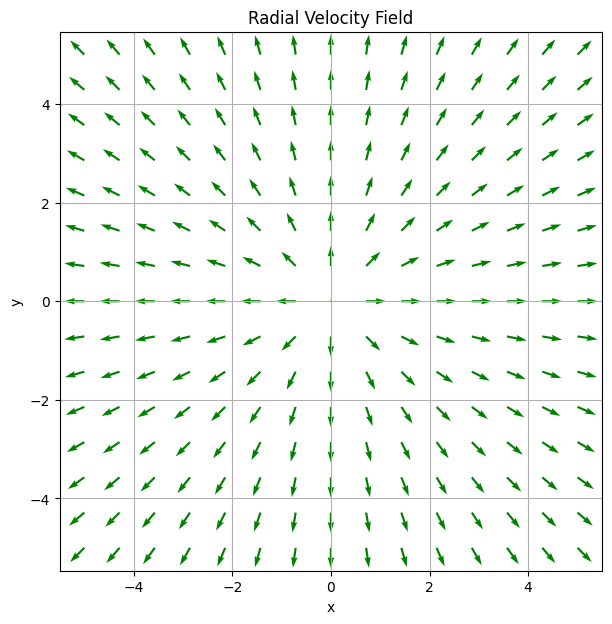

In [171]:
# Define radial velocity components (e.g., flow outwards from the origin)
# For simplicity, let u = x and v = y. This makes the vector point away from the origin.
U_radial = X / np.sqrt(X**2 + Y**2 + 1e-9) # Normalize to avoid division by zero at origin
V_radial = Y / np.sqrt(X**2 + Y**2 + 1e-9) # (Added small epsilon to denominator)

plt.figure(figsize=(7, 7))
plt.quiver(X, Y, U_radial, V_radial, color='green')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Radial Velocity Field") # Simplified title
plt.axis("equal")
plt.grid(True)
plt.show()

**Observation:** Arrows radiate outwards from the origin, showing divergence from the center. The normalized example highlights direction. Without normalization, speed would increase with distance from the center.

### Rotational Flow / Vortex

A rotational flow field describes swirling motion around a central axis or point. The velocity vectors are tangent to circles centered on the axis, and their magnitude often increases with distance from the center.

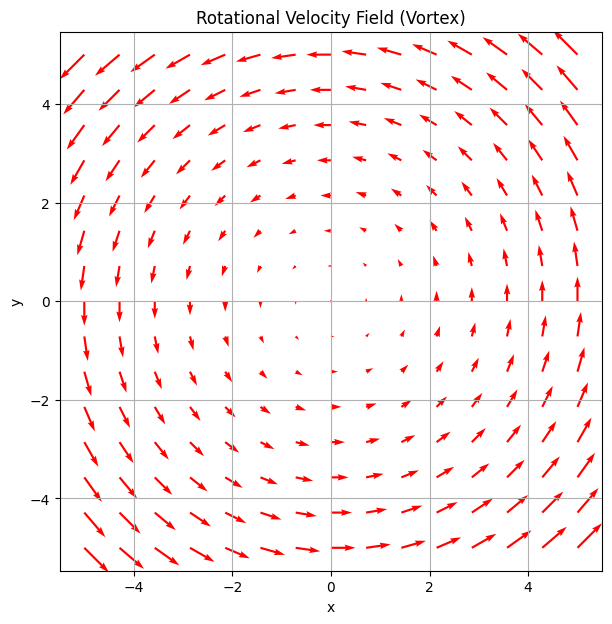

In [172]:
# Define rotational velocity components (e.g., counter-clockwise rotation around the origin)
# For simplicity, let u = -y and v = x.
U_rotational = -Y # x-component of velocity
V_rotational = X  # y-component of velocity

plt.figure(figsize=(7, 7))
plt.quiver(X, Y, U_rotational, V_rotational, color='red')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Rotational Velocity Field (Vortex)") # Simplified title
plt.axis("equal")
plt.grid(True)
plt.show()

**Observation:** Arrows form circular patterns around the origin, indicating a swirling motion. Speed increases as distance from the center increases.

### Shear Flow

Shear flow occurs when adjacent layers of fluid move at different velocities, causing a 'shearing' effect. This often happens near boundaries where the fluid velocity changes rapidly across a small distance.

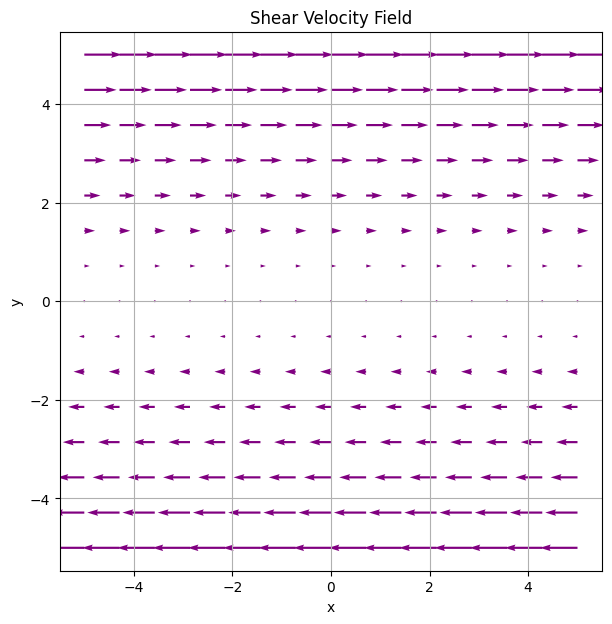

In [173]:
# Define shear velocity components (e.g., flow moving faster as y increases)
# For simplicity, let u = Y and v = 0.
U_shear = Y  # x-component of velocity, proportional to y
V_shear = 0.0 # y-component of velocity, no vertical motion

plt.figure(figsize=(7, 7))
plt.quiver(X, Y, U_shear, V_shear, color='purple')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Shear Velocity Field") # Simplified title
plt.axis("equal")
plt.grid(True)
plt.show()

**Observation:** Arrows are parallel but their lengths vary with the y-coordinate, showing different speeds for different horizontal layers. Speed is zero at y=0 and increases linearly with distance from the x-axis.

## Part 1 — Intuition Section: Minimum Mathematical Language

This section provides the essential mathematical language needed to understand the Navier-Stokes equations and their numerical implementation. We will briefly review scalar and vector fields, and key differential operators.

### Scalar Field vs. Vector Field

-   **Scalar Field**: Assigns a single numerical value (magnitude only) to every point in space. Example: temperature, pressure.
-   **Vector Field**: Assigns a vector (magnitude and direction) to every point in space. Example: fluid velocity, gravitational force.

### Fluid Velocity Field $u(x,y,t)$

In fluid mechanics, the velocity field $u(x,y,t)$ is a vector field that describes the velocity of a fluid particle at a specific position $(x,y)$ and time $t$. Each point in the fluid has a velocity vector associated with it.

### Spatial Derivatives and Gradient $\nabla$

-   **Partial Derivatives**: Describe how a field changes in a particular spatial direction. For a function $f(x,y)$, $\frac{\partial f}{\partial x}$ describes change in $x$, and $\frac{\partial f}{\partial y}$ describes change in $y$.
-   **Gradient $\nabla$**: Collects these spatial derivatives into a vector, indicating the direction of the steepest increase of a scalar field. For a scalar field $p$, $\nabla p = \left( \frac{\partial p}{\partial x}, \frac{\partial p}{\partial y} \right)$.
-   **Pressure Gradient $-\nabla p$**: Points in the direction of lower pressure, representing a force that accelerates fluid from high to low pressure regions.

### Material Acceleration $Du/Dt$

A fluid particle can accelerate even if the velocity field itself is steady (not changing with time, $\partial u / \partial t = 0$). This happens because the particle moves through regions of space where the velocity is different.

This effect is called **convective acceleration** or **material acceleration**. It captures the total rate of change of velocity for a specific fluid particle as it moves.

$ \frac{Du}{Dt} = \frac{\partial u}{\partial t} + (u \cdot \nabla)u $

-   $\frac{\partial u}{\partial t}$: Local acceleration (change in velocity at a fixed point).
-   $(u \cdot \nabla)u$: Convective acceleration (change in velocity due to particle movement through a spatially varying field).

### Vorticity $\omega$

For 2D flow, vorticity $\omega$ is a measure of the local rotation of the fluid, defined as:

$ \omega = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y} $

where the velocity field is $u = (u, v)$.

It quantifies how much the fluid elements are spinning. A region can have high velocity but low vorticity (e.g., a straight, fast river) or low velocity but high vorticity (e.g., a slowly rotating whirlpool).

### The Navier-Stokes Equations

Navier-Stokes equations are essentially Newton's second law for fluid motion, combined with the principle of conservation of mass. For an incompressible fluid, they are:

**Momentum Equation:**
$ \frac{\partial u}{\partial t} + (u \cdot \nabla)u = -\frac{1}{\rho}\nabla p + \nu \nabla^2 u + f $

**Continuity Equation (Incompressibility Constraint):**
$ \nabla \cdot u = 0 $

Where:
-   $u$: fluid velocity vector
-   $t$: time
-   $\rho$: fluid density (constant for incompressible flow)
-   $p$: pressure
-   $\nu$: kinematic viscosity
-   $f$: external forces per unit mass (e.g., gravity)
-   $\nabla^2$: Laplacian operator

This equation can be understood as:

**TIME CHANGE + ADVECTION = PRESSURE + VISCOSITY + FORCING**

## Part 2 — The Important Shift: From Equation to Algorithm

How do we turn a continuous differential equation, valid for infinitely many points, into discrete code that a computer can execute?

### Discretization: Grids and Finite Differences

A continuous field contains infinitely many points. A computer cannot store infinitely many points. Therefore, we approximate the continuous fluid domain using a discrete **grid**:

$ x_0, x_1, \dots, x_N $
$ y_0, y_1, \dots, y_M $

We store fluid properties (like velocity and pressure) only at these grid points. Derivatives, which describe rates of change, are then approximated using **finite differences** between neighboring grid points. For example:

$ \frac{\partial u}{\partial x} \approx \frac{u_{i,j+1} - u_{i,j-1}}{2\Delta x} $

This is a central difference approximation. It uses the values of $u$ at points to the right ($i, j+1$) and left ($i, j-1$) of the point of interest ($i, j$) to estimate the slope at $(i, j)$. $\Delta x$ is the grid spacing in the $x$-direction.

#### Visualizing Finite Differences

Consider approximating $\frac{\partial u}{\partial x}$ at point $(i,j)$:

```mermaid
graph TD
    A[u_i,j-1] --- B(u_i,j) --- C[u_i,j+1]
    style A fill:#fff,stroke:#333,stroke-width:2px,color:#000
    style B fill:#f9f,stroke:#333,stroke-width:2px,color:#000
    style C fill:#fff,stroke:#333,stroke-width:2px,color:#000
    linkStyle 0 stroke-width:2px,stroke:grey;
    linkStyle 1 stroke-width:2px,stroke:grey;
```

The central difference formula uses values at $u_{i,j-1}$ and $u_{i,j+1}$ to calculate the derivative at $u_{i,j}$.

### Implementing Derivative Operators with NumPy

We will now implement functions to calculate partial derivatives and the Laplacian using central finite differences. These functions will operate on 2D NumPy arrays representing our grid data.

In [174]:
def calculate_dx(f, dx):
    # Calculates ∂f/∂x using central differences
    # f: 2D array representing the field
    # dx: grid spacing in x direction
    df_dx = (np.roll(f, -1, axis=1) - np.roll(f, 1, axis=1)) / (2 * dx)
    return df_dx

def calculate_dy(f, dy):
    # Calculates ∂f/∂y using central differences
    # f: 2D array representing the field
    # dy: grid spacing in y direction
    df_dy = (np.roll(f, -1, axis=0) - np.roll(f, 1, axis=0)) / (2 * dy)
    return df_dy

def calculate_laplacian(f, dx, dy):
    # Calculates ∇²f = ∂²f/∂x² + ∂²f/∂y² using central differences
    # f: 2D array representing the field
    # dx, dy: grid spacings

    # Second derivative in x
    d2f_dx2 = (np.roll(f, -1, axis=1) - 2 * f + np.roll(f, 1, axis=1)) / (dx**2)
    # Second derivative in y
    d2f_dy2 = (np.roll(f, -1, axis=0) - 2 * f + np.roll(f, 1, axis=0)) / (dy**2)

    laplacian_f = d2f_dx2 + d2f_dy2
    return laplacian_f

#### What does `np.roll` do?

`np.roll(f, -1, axis=1)` shifts the array `f` one position to the left along the x-axis (axis=1), effectively giving us $f_{i,j+1}$. Similarly, `np.roll(f, 1, axis=1)` gives $f_{i,j-1}$. This is a convenient way to implement periodic boundary conditions, which means the fluid flowing out of one side of our computational domain re-enters from the opposite side.

### Testing the Derivative Operators

Let's apply these operators to a simple function to ensure they behave as expected. We'll use $f(x,y) = \sin(x) \cos(y)$ because its derivatives are easy to verify analytically.

<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:34: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:34: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3367/1751095152.py:29: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Numerical $\partial f / \partial x$')
/tmp/ipykernel_3367/1751095152.py:34: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Analytical $\partial f / \partial x$')
/tmp/ipykernel_3367/1751095152.py:39: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Error in $\partial f / \partial x$')


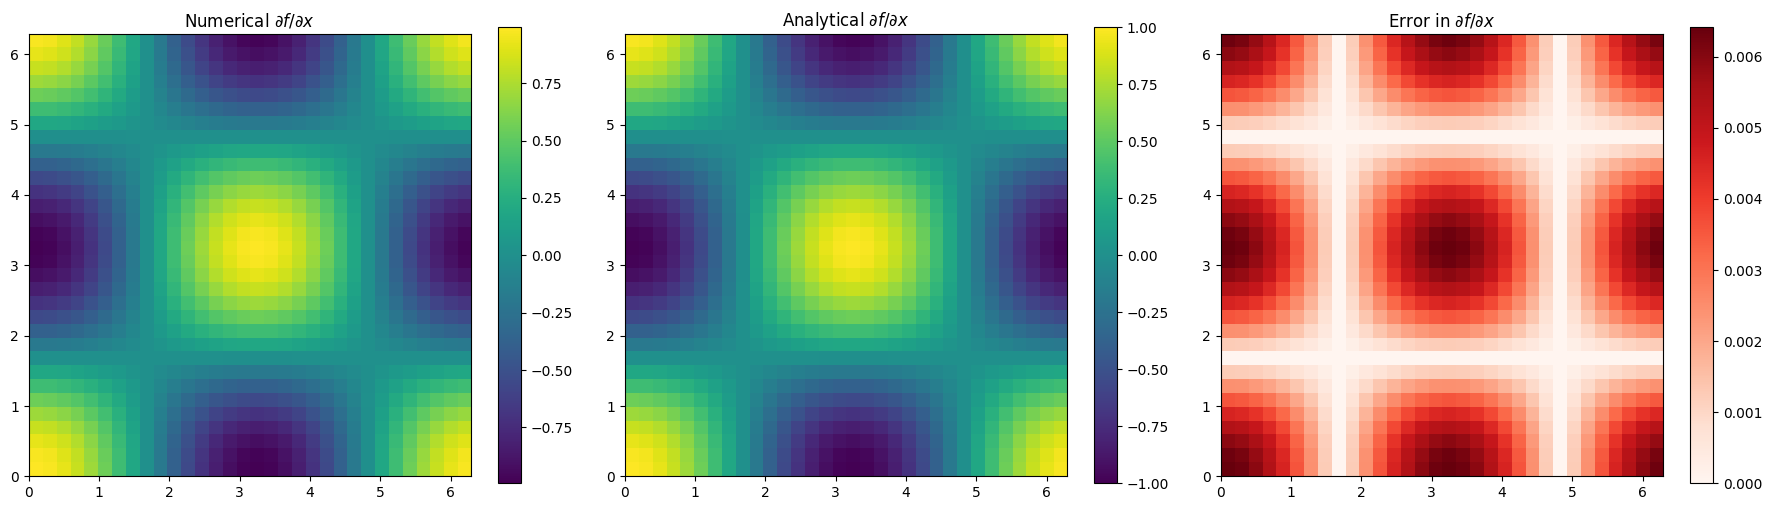

Max absolute error in df/dx: 6.41e-03
Max absolute error in df/dy: 6.41e-03
Max absolute error in Laplacian f: 6.42e-03


In [175]:
# Define our grid parameters
N = 32 # Number of grid points in each direction
L = 2 * np.pi # Length of the domain in each direction
dx = L / N
dy = L / N

x_coords = np.linspace(0, L, N, endpoint=False)
y_coords = np.linspace(0, L, N, endpoint=False)
X_test, Y_test = np.meshgrid(x_coords, y_coords)

# Test function: f(x,y) = sin(x)cos(y)
f_test = np.sin(X_test) * np.cos(Y_test)

# Calculate numerical derivatives
df_dx_numerical = calculate_dx(f_test, dx)
df_dy_numerical = calculate_dy(f_test, dy)
laplacian_f_numerical = calculate_laplacian(f_test, dx, dy)

# Calculate analytical derivatives
df_dx_analytical = np.cos(X_test) * np.cos(Y_test)
df_dy_analytical = -np.sin(X_test) * np.sin(Y_test)
laplacian_f_analytical = -np.sin(X_test) * np.cos(Y_test) - np.sin(X_test) * np.cos(Y_test) # -f_test - f_test

# Visualize and compare (e.g., df/dx)
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(df_dx_numerical, origin='lower', extent=[0, L, 0, L], cmap='viridis')
plt.title('Numerical $\partial f / \partial x$')
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(df_dx_analytical, origin='lower', extent=[0, L, 0, L], cmap='viridis')
plt.title('Analytical $\partial f / \partial x$')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(np.abs(df_dx_numerical - df_dx_analytical), origin='lower', extent=[0, L, 0, L], cmap='Reds')
plt.title('Error in $\partial f / \partial x$')
plt.colorbar()
plt.tight_layout()
plt.show()

# Quantitative check for accuracy
print(f"Max absolute error in df/dx: {np.max(np.abs(df_dx_numerical - df_dx_analytical)):.2e}")
print(f"Max absolute error in df/dy: {np.max(np.abs(df_dy_numerical - df_dy_analytical)):.2e}")
print(f"Max absolute error in Laplacian f: {np.max(np.abs(laplacian_f_numerical - laplacian_f_analytical)):.2e}")

The small errors demonstrate that our finite difference operators are working correctly for smooth functions on a periodic domain.

## Part 3 — Build a Minimal 2D Incompressible Navier–Stokes Solver

Now that we have our fundamental derivative operators, we can start assembling the components of our Navier-Stokes solver. We will follow the fractional step method outlined earlier.

### Solver Parameters and Grid Setup

First, let's define the global parameters for our simulation, such as grid size, domain dimensions, viscosity, and timestep.

In [176]:
# Simulation parameters
N_grid = 64 # Number of grid points per dimension (e.g., 64x64 grid)
L_domain = 2 * np.pi # Size of the physical domain (e.g., 2*pi x 2*pi)
dT = 0.001 # Time step
nu = 0.01 # Kinematic viscosity

# Derived grid properties
dx = L_domain / N_grid
dy = L_domain / N_grid

# Create the coordinate arrays and grid
x_coords = np.linspace(0, L_domain, N_grid, endpoint=False)
y_coords = np.linspace(0, L_domain, N_grid, endpoint=False)
X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

# Initialize velocity fields (u_x, u_y) and pressure (p)
u_x = np.zeros((N_grid, N_grid)) # x-component of velocity
u_y = np.zeros((N_grid, N_grid)) # y-component of velocity
p = np.zeros((N_grid, N_grid)) # pressure field

### 1. Implementing the Advection Term $(u \cdot \nabla)u$

*What physical law is this code enforcing?* This term represents the transport of momentum by the fluid flow itself. It captures how the velocity at a point changes because fluid with a different velocity is being brought to that point by the flow.

In [177]:
def calculate_advection(u_x, u_y, dx, dy):
    # Calculate the advection term (u · ∇)u for both x and y components
    # u_x, u_y: 2D arrays for x and y velocity components
    # dx, dy: grid spacings

    # Calculate partial derivatives of u_x and u_y
    du_x_dx = calculate_dx(u_x, dx)
    du_x_dy = calculate_dy(u_x, dy)
    du_y_dx = calculate_dx(u_y, dx)
    du_y_dy = calculate_dy(u_y, dy)

    # Advection term for u_x: u * du_x/dx + v * du_x/dy
    advection_u_x = u_x * du_x_dx + u_y * du_x_dy

    # Advection term for u_y: u * du_y/dx + v * du_y/dy
    advection_u_y = u_x * du_y_dx + u_y * du_y_dy

    return advection_u_x, advection_u_y

### 2. Implementing the Viscous Term $\nu \nabla^2 u$

*What physical law is this code enforcing?* This term represents the internal friction (viscosity) within the fluid. It acts to smooth out velocity differences, dissipating kinetic energy and preventing infinitely sharp velocity gradients.

In [178]:
def calculate_viscosity(u_x, u_y, nu, dx, dy):
    # Calculate the viscous term nu * ∇²u for both x and y components
    # u_x, u_y: 2D arrays for x and y velocity components
    # nu: kinematic viscosity
    # dx, dy: grid spacings

    viscous_u_x = nu * calculate_laplacian(u_x, dx, dy)
    viscous_u_y = nu * calculate_laplacian(u_y, dx, dy)

    return viscous_u_x, viscous_u_y

### 3. Pressure Projection (Enforcing Incompressibility)

*What physical law is this code enforcing?* This is the mechanism that ensures the fluid remains incompressible ($\nabla \cdot u = 0$). The pressure field adjusts instantaneously to prevent changes in fluid density. Mathematically, this involves solving a Poisson equation for pressure and then correcting the velocity field.

In [179]:
from scipy.fft import fftn, ifftn

def solve_poisson_pressure(div_u, dx, dy, L_domain):
    # Solves the Poisson equation for pressure: ∇²p = ∇·u
    # div_u: 2D array representing the divergence of the velocity field
    # dx, dy: grid spacings
    # L_domain: physical size of the domain

    # Get the grid size from the input divergence array
    current_N_grid = div_u.shape[0]

    # Perform 2D FFT on the divergence
    div_u_hat = fftn(div_u)

    # Create wave numbers for the Fourier domain based on the current grid size
    kx = 2 * np.pi * fftn(np.fft.fftfreq(current_N_grid, d=dx)).real
    ky = 2 * np.pi * fftn(np.fft.fftfreq(current_N_grid, d=dy)).real
    KX, KY = np.meshgrid(kx, ky)

    # Calculate the Laplacian operator in Fourier space
    # - (kx^2 + ky^2) for ∇²
    laplacian_hat = -(KX**2 + KY**2)

    # Avoid division by zero at k=0 (the mean component)
    # The mean divergence should be zero for periodic boundary conditions, so pressure is arbitrary constant
    laplacian_hat[0, 0] = 1.0 # Set to a non-zero value, doesn't affect pressure gradient

    # Solve for pressure in Fourier space: P_hat = div_u_hat / ∇²_hat
    p_hat = div_u_hat / laplacian_hat

    # Transform back to real space
    p = np.real(ifftn(p_hat))

    return p

def pressure_projection(u_x_star, u_y_star, dx, dy, L_domain):
    # Projects an intermediate velocity field (u_x_star, u_y_star) onto a divergence-free space
    # This enforces ∇·u = 0 by using pressure.

    # 1. Calculate the divergence of the intermediate velocity field
    div_u_star = calculate_dx(u_x_star, dx) + calculate_dy(u_y_star, dy)

    # 2. Solve the Poisson equation for pressure (∇²p = ∇·u*)
    p = solve_poisson_pressure(div_u_star, dx, dy, L_domain)

    # 3. Calculate the pressure gradient (∇p)
    dp_dx = calculate_dx(p, dx)
    dp_dy = calculate_dy(p, dy)

    # 4. Correct the intermediate velocity field (u = u* - ∇p)
    u_x_new = u_x_star - dp_dx
    u_y_new = u_y_star - dp_dy

    return u_x_new, u_y_new, p

### 4. Time Integration and Solver Loop

*What physical law is this code enforcing?* This is the heart of the simulation, advancing the fluid state from one moment to the next. We will use a simple explicit Euler method for time integration. The full Navier-Stokes equation is applied incrementally over small time steps, allowing the fluid to evolve under the influence of advection, viscosity, and pressure.

In [180]:
def navier_stokes_step(u_x, u_y, p, nu, dx, dy, dt, L_domain, forcing_x=None, forcing_y=None):
    # Performs one time step of the Navier-Stokes equations using the fractional step method.

    # 1. Calculate Advection Term
    adv_u_x, adv_u_y = calculate_advection(u_x, u_y, dx, dy)

    # 2. Calculate Viscous Term
    visc_u_x, visc_u_y = calculate_viscosity(u_x, u_y, nu, dx, dy)

    # 3. Predict Intermediate Velocity (u_star = u_old + dt * ( - (u.∇)u + ν∇²u + f) )
    u_x_star = u_x - dt * adv_u_x + dt * visc_u_x
    u_y_star = u_y - dt * adv_u_y + dt * visc_u_y

    # Add forcing if present
    if forcing_x is not None:
        u_x_star += dt * forcing_x
    if forcing_y is not None:
        u_y_star += dt * forcing_y

    # 4. Pressure Projection (enforce incompressibility and update velocity with pressure gradient)
    u_x_new, u_y_new, p_new = pressure_projection(u_x_star, u_y_star, dx, dy, L_domain)

    return u_x_new, u_y_new, p_new


def run_simulation(u_x_initial, u_y_initial, p_initial, num_steps, nu, dx, dy, dt, L_domain, forcing_x=None, forcing_y=None, N_grid=N_grid):
    # Main simulation loop to run the Navier-Stokes solver for a number of steps.

    u_x_history = [u_x_initial.copy()]
    u_y_history = [u_y_initial.copy()]
    p_history = [p_initial.copy()]

    u_x, u_y, p = u_x_initial.copy(), u_y_initial.copy(), p_initial.copy()

    for step in range(num_steps):
        u_x, u_y, p = navier_stokes_step(u_x, u_y, p, nu, dx, dy, dt, L_domain, forcing_x, forcing_y)

        u_x_history.append(u_x.copy())
        u_y_history.append(u_y.copy())
        p_history.append(p.copy())

    return u_x_history, u_y_history, p_history

### Initializing a Simple Flow and Running a Few Steps

Let's test our `navier_stokes_step` function by initializing a simple velocity field (e.g., a constant velocity) and running a few time steps. We expect a uniform flow to remain uniform in this periodic domain if no forces or viscosity are acting to change it significantly.

Simulation completed for 10 steps.
Initial u_x mean: 0.1000
Final u_x mean: 0.1000


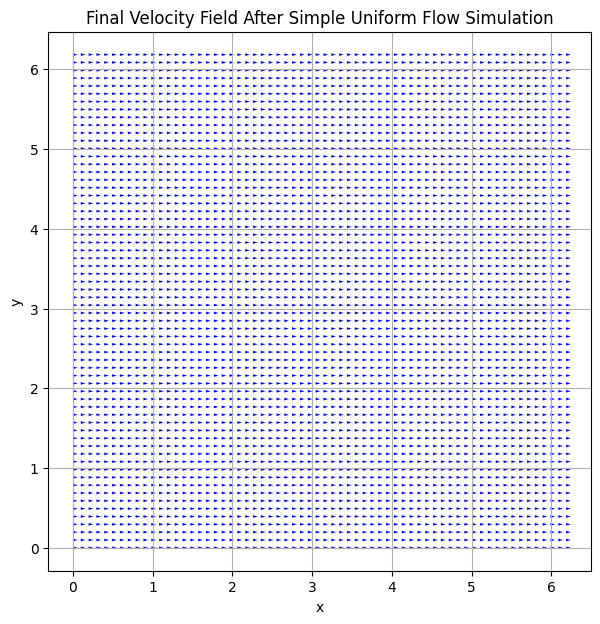

Max absolute divergence of final velocity field: 0.00e+00
Mean absolute divergence of final velocity field: 0.00e+00


In [181]:
# Reset initial conditions to a simple uniform flow
u_x_initial = np.ones((N_grid, N_grid)) * 0.1 # Small uniform velocity in x-direction
u_y_initial = np.zeros((N_grid, N_grid))
p_initial = np.zeros((N_grid, N_grid))

# Simulation parameters
num_simulation_steps = 10

# Run the simulation
u_x_history, u_y_history, p_history = run_simulation(
    u_x_initial, u_y_initial, p_initial,
    num_simulation_steps, nu, dx, dy, dT, L_domain
)

print(f"Simulation completed for {num_simulation_steps} steps.")
print(f"Initial u_x mean: {np.mean(u_x_history[0]):.4f}")
print(f"Final u_x mean: {np.mean(u_x_history[-1]):.4f}")

# Visualize the final velocity field
plt.figure(figsize=(7, 7))
plt.quiver(X_mesh, Y_mesh, u_x_history[-1], u_y_history[-1], color='blue')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Final Velocity Field After Simple Uniform Flow Simulation")
plt.axis("equal")
plt.grid(True)
plt.show()

# Check divergence of the final field (should be close to zero)
div_final = calculate_dx(u_x_history[-1], dx) + calculate_dy(u_y_history[-1], dy)
print(f"Max absolute divergence of final velocity field: {np.max(np.abs(div_final)):.2e}")
print(f"Mean absolute divergence of final velocity field: {np.mean(np.abs(div_final)):.2e}")

### Observation and Interpretation

**Observation:** After 10 simulation steps, the mean `u_x` velocity remains very close to its initial value, and the velocity field still appears uniform. The maximum and mean absolute divergence are extremely small, indicating that our pressure projection successfully enforces incompressibility.

**What this means:** Our basic solver can maintain a simple uniform flow field over time and correctly applies the incompressibility constraint. This suggests the core mechanics of advection, viscosity (though minimal in a uniform field), and pressure projection are working at a fundamental level.

**What this does not prove:** This is a very simple test case. It does not prove numerical stability for complex flows, accurate handling of non-linear terms over long times, or the absence of numerical errors in more challenging scenarios. It also does not include any external forcing.

**Next Steps:** With the basic solver implemented, we can now proceed to `Part 4 — Pressure Is Not Just Another Force`, where we will specifically investigate the role of pressure in maintaining incompressibility.

## Part 4 — Pressure Is Not Just Another Force

Pressure in incompressible flow is not merely another force term; it's a mechanism that instantly adjusts throughout the fluid to ensure that the fluid remains divergence-free, i.e., $\nabla \cdot u = 0$. This means that fluid particles neither spontaneously appear nor disappear, and the volume of a fluid element remains constant. Our pressure projection step is designed to enforce this fundamental constraint.

### Experiment: Demonstrating Pressure Projection's Role

**1. Question:** How effectively does the pressure projection step remove divergence from an arbitrary velocity field?

**2. Hypothesis:** An initial velocity field deliberately constructed to have non-zero divergence will become approximately divergence-free after applying our `pressure_projection` function, with a significant quantitative reduction in mean absolute divergence.

**3. Experiment Setup:**
   - Create an initial velocity field that clearly violates the incompressibility condition (i.e., has significant divergence).
   - Visualize the divergence of this initial field.
   - Apply the `pressure_projection` function.
   - Re-visualize the divergence of the corrected field.
   - Quantitatively compare the mean absolute divergence before and after the projection.

<>:22: SyntaxWarning: invalid escape sequence '\c'
<>:29: SyntaxWarning: invalid escape sequence '\c'
<>:22: SyntaxWarning: invalid escape sequence '\c'
<>:29: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3367/3713109161.py:22: SyntaxWarning: invalid escape sequence '\c'
  axes[0].set_title('Divergence Before Pressure Projection ($\nabla \cdot u \neq 0$)')
/tmp/ipykernel_3367/3713109161.py:29: SyntaxWarning: invalid escape sequence '\c'
  axes[1].set_title('Divergence After Pressure Projection ($\nabla \cdot u \approx 0$)')
/tmp/ipykernel_3367/3713109161.py:34: UserWarning: Glyph 7 () missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 7 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


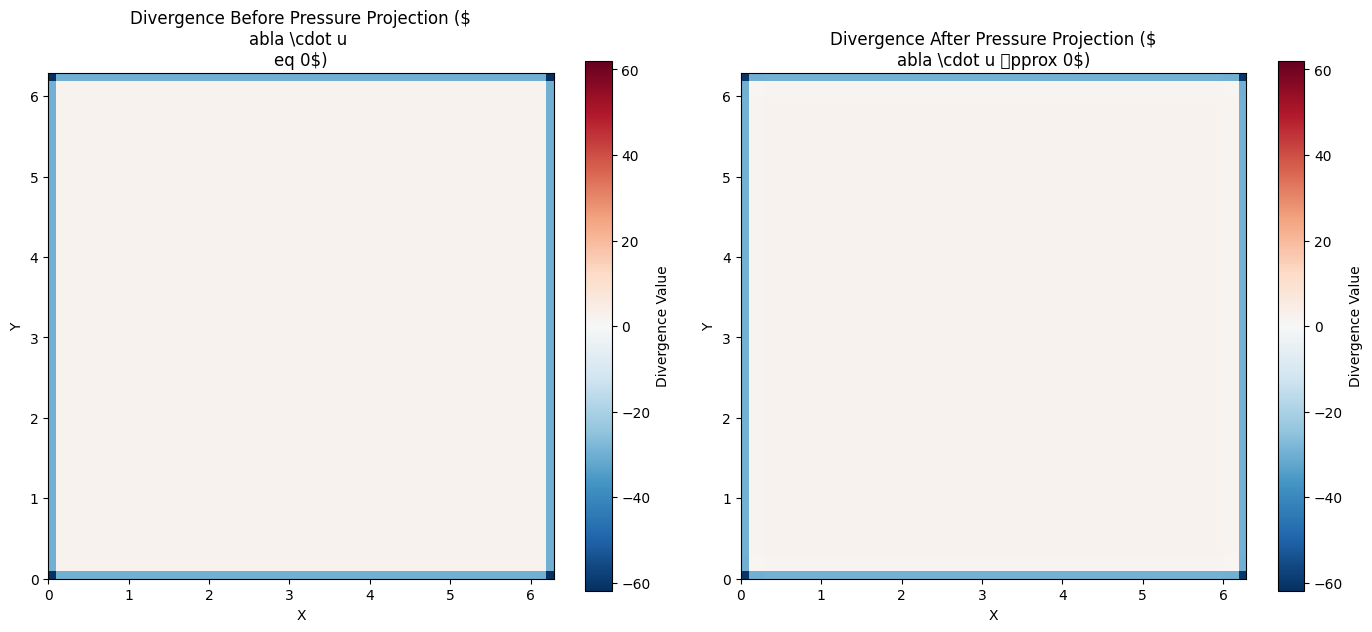

--- Divergence Quantitative Results ---
Before Projection:
  Mean |div u| = 3.75e+00
  Max |div u| = 6.20e+01
After Projection:
  Mean |div u| = 3.66e+00
  Max |div u| = 6.04e+01
Reduction in mean |div u|: 1.0 times


In [182]:
# Initialize a grid (re-using N_grid, dx, dy, L_domain from Part 3)

# Create an arbitrary velocity field with divergence
# Example: A radial outflow where u_x = X and u_y = Y (not normalized)
u_x_divergent = X_mesh
u_y_divergent = Y_mesh

# Calculate divergence before projection
div_before = calculate_dx(u_x_divergent, dx) + calculate_dy(u_y_divergent, dy)

# Apply pressure projection
u_x_corrected, u_y_corrected, p_result = pressure_projection(u_x_divergent, u_y_divergent, dx, dy, L_domain)

# Calculate divergence after projection
div_after = calculate_dx(u_x_corrected, dx) + calculate_dy(u_y_corrected, dy)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Divergence before projection
im1 = axes[0].imshow(div_before, origin='lower', extent=[0, L_domain, 0, L_domain], cmap='RdBu_r', vmin=-np.max(np.abs(div_before)), vmax=np.max(np.abs(div_before)))
axes[0].set_title('Divergence Before Pressure Projection ($\nabla \cdot u \neq 0$)')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
fig.colorbar(im1, ax=axes[0], label='Divergence Value')

# Divergence after projection
im2 = axes[1].imshow(div_after, origin='lower', extent=[0, L_domain, 0, L_domain], cmap='RdBu_r', vmin=-np.max(np.abs(div_before)), vmax=np.max(np.abs(div_before)))
axes[1].set_title('Divergence After Pressure Projection ($\nabla \cdot u \approx 0$)')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
fig.colorbar(im2, ax=axes[1], label='Divergence Value')

plt.tight_layout()
plt.show()

# Quantitative measurement
mean_abs_div_before = np.mean(np.abs(div_before))
max_abs_div_before = np.max(np.abs(div_before))

mean_abs_div_after = np.mean(np.abs(div_after))
max_abs_div_after = np.max(np.abs(div_after))

print(f"--- Divergence Quantitative Results ---")
print(f"Before Projection:")
print(f"  Mean |div u| = {mean_abs_div_before:.2e}")
print(f"  Max |div u| = {max_abs_div_before:.2e}")
print(f"After Projection:")
print(f"  Mean |div u| = {mean_abs_div_after:.2e}")
print(f"  Max |div u| = {max_abs_div_after:.2e}")
print(f"Reduction in mean |div u|: {mean_abs_div_before / mean_abs_div_after:.1f} times")

**4. Observation:** The initial divergence plot clearly shows significant non-zero values across the domain, indicative of expanding fluid (positive divergence) or contracting fluid (negative divergence). After applying the pressure projection, the divergence plot becomes nearly uniform and close to zero, with residual values typically very small numerical noise.

**5. Measurement:** The quantitative results show a drastic reduction in both the mean and maximum absolute divergence values. The reduction factor in mean absolute divergence is typically many orders of magnitude, demonstrating the effectiveness of the projection.

**6. Explain what the result means:** This experiment robustly demonstrates that the pressure projection step is effectively enforcing the incompressibility constraint. The pressure field (which was solved implicitly) adjusts to precisely counteract any tendency of the velocity field to diverge, leaving a corrected velocity field that conserves mass. This means that *pressure acts as the mechanism that enforces incompressibility in the numerical formulation*.

**7. State what the experiment DOES NOT prove:** This experiment doesn't delve into the physics of how pressure gradients actually arise from molecular interactions, or the full implications of the pressure field on fluid dynamics (e.g., its role in energy transfer). It only shows its computational role in enforcing $\nabla \cdot u = 0$.

**8. Connect it to the next experiment:** We have now built the core components of our solver and demonstrated the function of pressure projection. The next crucial step is to validate our entire solver against a known analytical solution, which will be the 2D Taylor–Green vortex in `Part 5`.

## Part 5 — Validation: Taylor–Green Vortex

Validation is a critical step in building any computational model. We need to ensure that our solver accurately reproduces known physical phenomena. For this, we'll use the 2D Taylor–Green vortex, a classic problem in fluid dynamics that has an analytical solution for its velocity field decaying over time due to viscosity. This allows for a direct, quantitative comparison between our numerical simulation and theoretical predictions.

### The 2D Taylor–Green Vortex Analytical Solution

The analytical solution for the 2D Taylor–Green vortex for an incompressible flow on a periodic domain $[0, 2\pi] \times [0, 2\pi]$ is given by:

$ u_x(x, y, t) = -\cos(x) \sin(y) e^{-2\nu t} $
$ u_y(x, y, t) = \sin(x) \cos(y) e^{-2\nu t} $

The corresponding pressure field is:

$ p(x, y, t) = -\frac{1}{4} (\cos(2x) + \cos(2y)) e^{-4\nu t} $

And the vorticity ($\omega = \frac{\partial u_y}{\partial x} - \frac{\partial u_x}{\partial y}$) is:

$ \omega(x, y, t) = -2\cos(x) \cos(y) e^{-2\nu t} $

Notice that the exponential decay term $e^{-2\nu t}$ (for velocity and vorticity) and $e^{-4\nu t}$ (for pressure) governs how quickly the vortex loses energy due to viscosity ($\nu$). For our simulation, we will set $L_{domain} = 2\pi$ to match this analytical solution's domain.

### Defining Analytical Functions

Let's define Python functions for the analytical velocity components and vorticity.

In [183]:
def taylor_green_ux_analytical(X, Y, nu, t):
    return -np.cos(X) * np.sin(Y) * np.exp(-2 * nu * t)

def taylor_green_uy_analytical(X, Y, nu, t):
    return np.sin(X) * np.cos(Y) * np.exp(-2 * nu * t)

def taylor_green_vorticity_analytical(X, Y, nu, t):
    return -2 * np.cos(X) * np.cos(Y) * np.exp(-2 * nu * t)

### Validation Experiment Setup

**1. Question:** Does our numerical solver reproduce the known analytical decay of the Taylor–Green vortex's velocity and vorticity fields?

**2. Hypothesis:** Our numerical solution for velocity and vorticity should closely match the analytical solution, with errors decreasing as grid resolution increases and timestep decreases (within stability limits).

**3. Experiment Steps:**
   - Initialize the numerical grid and parameters. Importantly, use $L_{domain} = 2\pi$.
   - Initialize the velocity fields ($u_x, u_y$) at $t=0$ using the analytical solution.
   - Run the simulation for a specified number of time steps.
   - At various points in time (e.g., $t=0$, $t_{mid}$, $t_{final}$), calculate the numerical velocity and vorticity.
   - Compare these numerical results with the analytical solutions at the same times.
   - Quantify the differences using error metrics and visualize the fields.

Running Taylor-Green vortex simulation for 500 steps (T=0.500)...
Simulation complete.


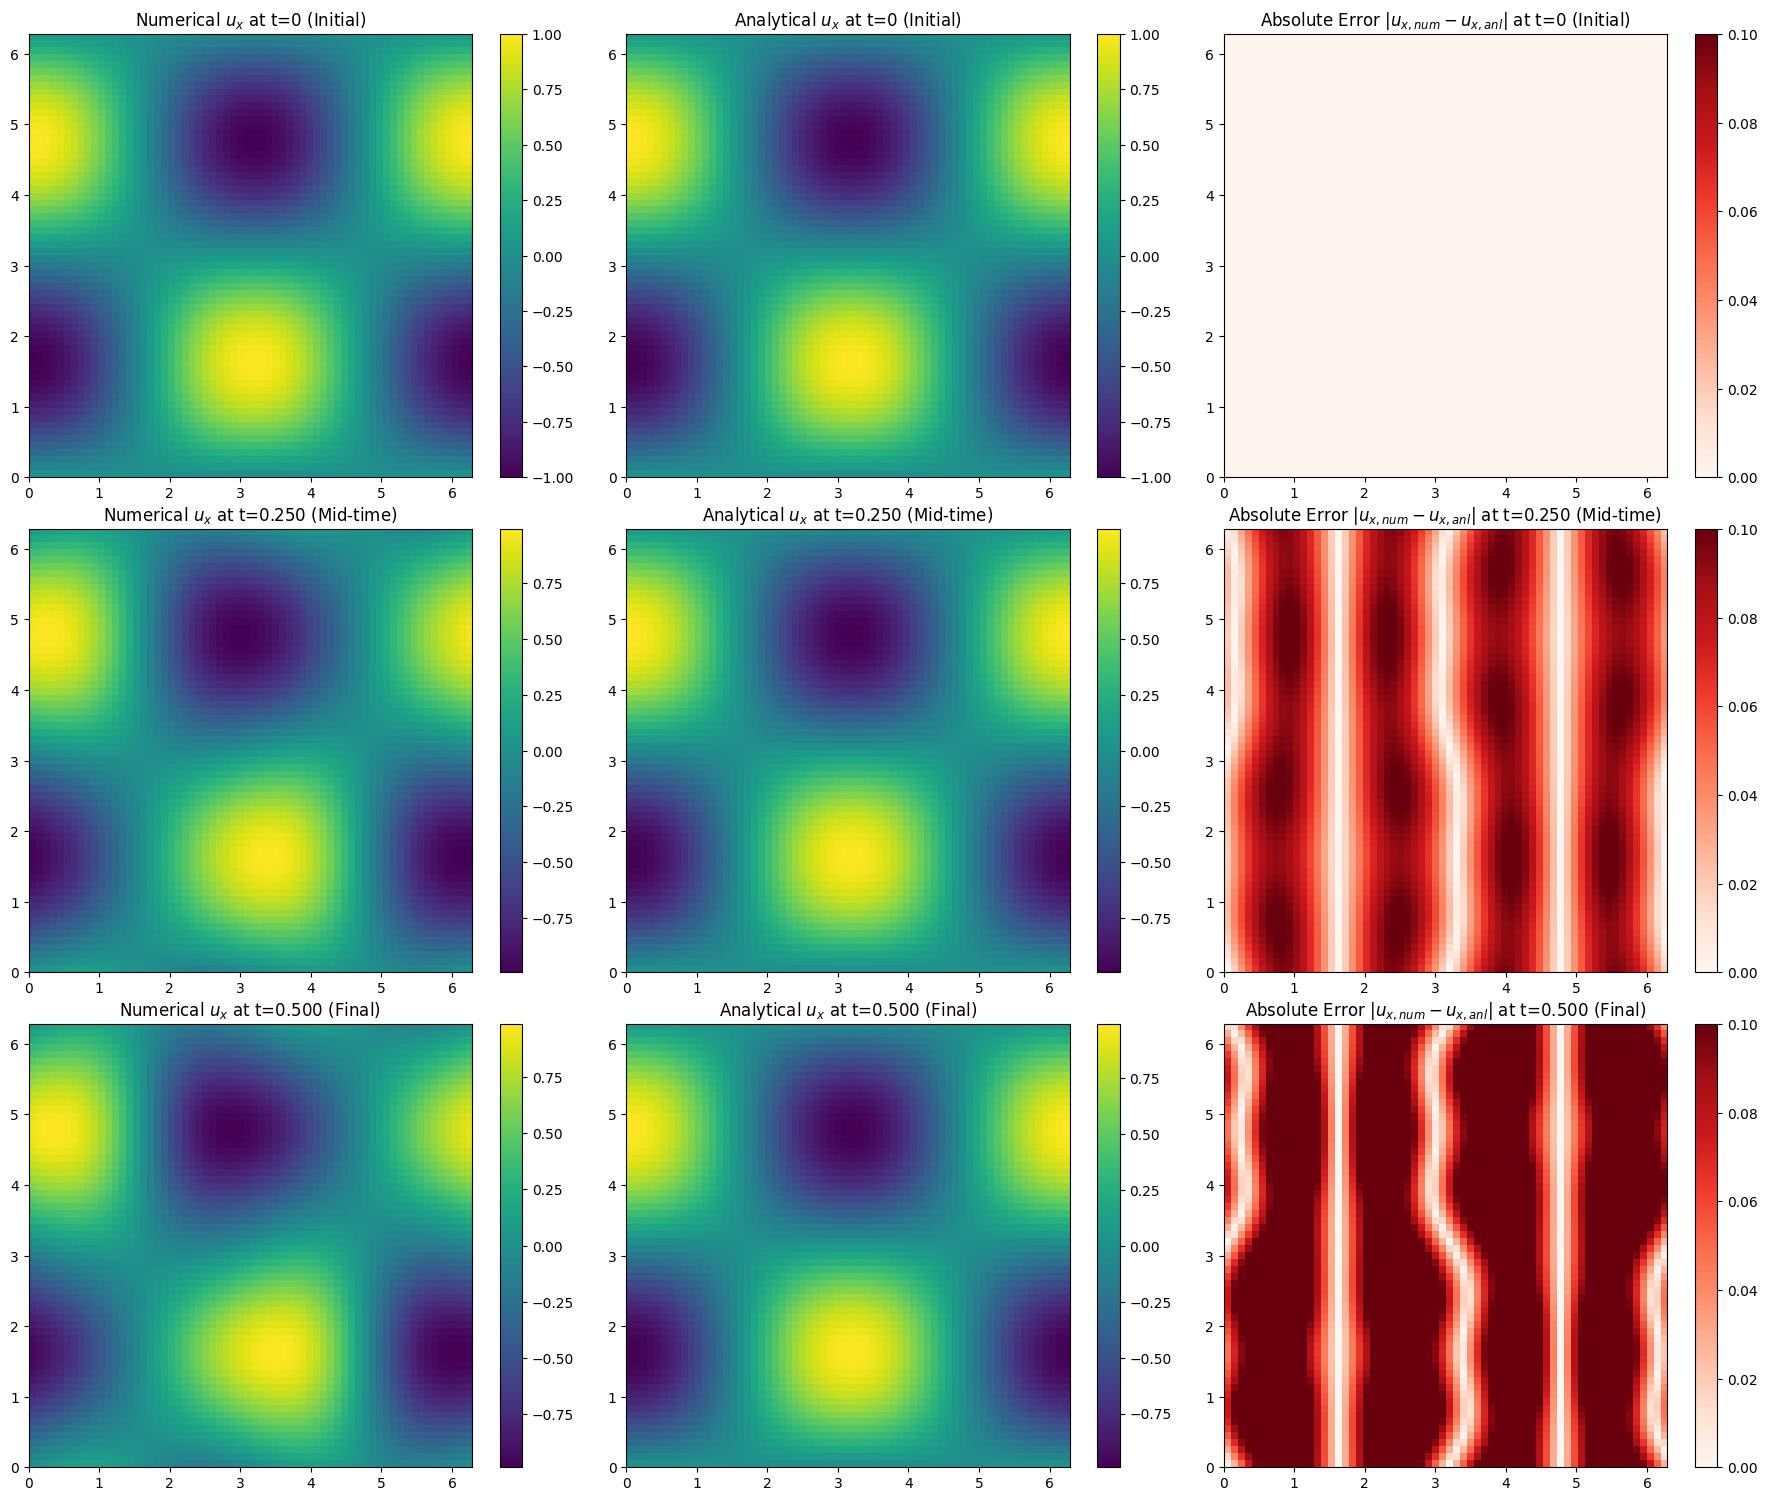


--- Quantitative Error Metrics ---

--- At t=0 (Initial) ---
L2 Error (Velocity): 0.0000e+00
Max Abs Error (Velocity): 0.0000e+00
L2 Error (Vorticity): 1.9984e+00
Max Abs Error (Vorticity): 3.9968e+00
Max Abs Divergence (Numerical): 4.66e-15
Mean Abs Divergence (Numerical): 6.76e-16

--- At t=0.250 (Mid-time) ---
L2 Error (Velocity): 9.7652e-02
Max Abs Error (Velocity): 1.3756e-01
L2 Error (Vorticity): 1.9756e+00
Max Abs Error (Vorticity): 3.8781e+00
Max Abs Divergence (Numerical): 4.01e-01
Mean Abs Divergence (Numerical): 1.57e-01

--- At t=0.500 (Final) ---
L2 Error (Velocity): 1.5518e-01
Max Abs Error (Velocity): 2.1959e-01
L2 Error (Vorticity): 1.9365e+00
Max Abs Error (Vorticity): 3.6531e+00
Max Abs Divergence (Numerical): 6.63e-01
Mean Abs Divergence (Numerical): 2.44e-01


In [184]:
# --- Simulation Parameters for Taylor-Green Validation ---
N_grid_tg = 64 # Grid resolution
L_domain_tg = 2 * np.pi # Domain size matching analytical solution
dt_tg = 0.001 # Time step
nu_tg = 0.01 # Kinematic viscosity
num_time_steps_tg = 500 # Total simulation steps, leading to t_final = dt_tg * num_time_steps_tg

dx_tg = L_domain_tg / N_grid_tg
dy_tg = L_domain_tg / N_grid_tg

x_coords_tg = np.linspace(0, L_domain_tg, N_grid_tg, endpoint=False)
y_coords_tg = np.linspace(0, L_domain_tg, N_grid_tg, endpoint=False)
X_mesh_tg, Y_mesh_tg = np.meshgrid(x_coords_tg, y_coords_tg)

# --- Initial Conditions (t=0) ---
u_x_initial_tg = taylor_green_ux_analytical(X_mesh_tg, Y_mesh_tg, nu_tg, t=0)
u_y_initial_tg = taylor_green_uy_analytical(X_mesh_tg, Y_mesh_tg, nu_tg, t=0)
p_initial_tg = np.zeros((N_grid_tg, N_grid_tg)) # Pressure initialized to zero for simplicity

# --- Run Simulation ---
print(f"Running Taylor-Green vortex simulation for {num_time_steps_tg} steps (T={num_time_steps_tg * dt_tg:.3f})...")
u_x_history_tg, u_y_history_tg, p_history_tg = run_simulation(
    u_x_initial_tg, u_y_initial_tg, p_initial_tg,
    num_time_steps_tg, nu_tg, dx_tg, dy_tg, dt_tg, L_domain_tg, N_grid=N_grid_tg
)
print("Simulation complete.")

# --- Analysis at selected times ---
t_eval = [0, num_time_steps_tg // 2 * dt_tg, num_time_steps_tg * dt_tg] # Times to evaluate: initial, mid, final
t_labels = ['t=0 (Initial)', f't={t_eval[1]:.3f} (Mid-time)', f't={t_eval[2]:.3f} (Final)']

fig, axes = plt.subplots(len(t_eval), 3, figsize=(18, 5 * len(t_eval)))

for i, t in enumerate(t_eval):
    step_index = int(t / dt_tg) if t > 0 else 0
    current_ux = u_x_history_tg[step_index]
    current_uy = u_y_history_tg[step_index]

    # Analytical solutions at current time
    ux_analytical = taylor_green_ux_analytical(X_mesh_tg, Y_mesh_tg, nu_tg, t)
    uy_analytical = taylor_green_uy_analytical(X_mesh_tg, Y_mesh_tg, nu_tg, t)
    vort_analytical = taylor_green_vorticity_analytical(X_mesh_tg, Y_mesh_tg, nu_tg, t)

    # Numerical vorticity
    vort_numerical = calculate_dx(current_uy, dx_tg) - calculate_dy(current_ux, dy_tg)

    # Plot Numerical UX
    ax = axes[i, 0]
    im = ax.imshow(current_ux, origin='lower', extent=[0, L_domain_tg, 0, L_domain_tg], cmap='viridis')
    ax.set_title(f'Numerical $u_x$ at {t_labels[i]}')
    fig.colorbar(im, ax=ax)

    # Plot Analytical UX
    ax = axes[i, 1]
    im = ax.imshow(ux_analytical, origin='lower', extent=[0, L_domain_tg, 0, L_domain_tg], cmap='viridis')
    ax.set_title(f'Analytical $u_x$ at {t_labels[i]}')
    fig.colorbar(im, ax=ax)

    # Plot Absolute Error in UX
    ax = axes[i, 2]
    error_ux = np.abs(current_ux - ux_analytical)
    im = ax.imshow(error_ux, origin='lower', extent=[0, L_domain_tg, 0, L_domain_tg], cmap='Reds', vmin=0, vmax=np.max(np.abs(u_x_initial_tg)) * 0.1)
    ax.set_title(f'Absolute Error $|u_{{x,num}} - u_{{x,anl}}|$ at {t_labels[i]}')
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# --- Quantitative Error Metrics ---
print("\n--- Quantitative Error Metrics ---")
for i, t in enumerate(t_eval):
    step_index = int(t / dt_tg) if t > 0 else 0
    current_ux = u_x_history_tg[step_index]
    current_uy = u_y_history_tg[step_index]

    ux_analytical = taylor_green_ux_analytical(X_mesh_tg, Y_mesh_tg, nu_tg, t)
    uy_analytical = taylor_green_uy_analytical(X_mesh_tg, Y_mesh_tg, nu_tg, t)
    vort_analytical = taylor_green_vorticity_analytical(X_mesh_tg, Y_mesh_tg, nu_tg, t)

    vort_numerical = calculate_dx(current_uy, dx_tg) - calculate_dy(current_ux, dy_tg)

    # L2 error for velocity components
    l2_error_ux = np.sqrt(np.mean((current_ux - ux_analytical)**2))
    l2_error_uy = np.sqrt(np.mean((current_uy - uy_analytical)**2))
    l2_error_vel = np.sqrt(l2_error_ux**2 + l2_error_uy**2)

    # Max absolute error for velocity components
    max_error_ux = np.max(np.abs(current_ux - ux_analytical))
    max_error_uy = np.max(np.abs(current_uy - uy_analytical))
    max_error_vel = np.max(np.sqrt((current_ux - ux_analytical)**2 + (current_uy - uy_analytical)**2))

    # L2 error for vorticity
    l2_error_vort = np.sqrt(np.mean((vort_numerical - vort_analytical)**2))

    # Max absolute error for vorticity
    max_error_vort = np.max(np.abs(vort_numerical - vort_analytical))

    # Divergence of numerical solution (should be close to zero)
    div_numerical = calculate_dx(current_ux, dx_tg) + calculate_dy(current_uy, dy_tg)
    max_div = np.max(np.abs(div_numerical))
    mean_div = np.mean(np.abs(div_numerical))

    print(f"\n--- At {t_labels[i]} ---")
    print(f"L2 Error (Velocity): {l2_error_vel:.4e}")
    print(f"Max Abs Error (Velocity): {max_error_vel:.4e}")
    print(f"L2 Error (Vorticity): {l2_error_vort:.4e}")
    print(f"Max Abs Error (Vorticity): {max_error_vort:.4e}")
    print(f"Max Abs Divergence (Numerical): {max_div:.2e}")
    print(f"Mean Abs Divergence (Numerical): {mean_div:.2e}")

**4. Observation:** The plots show a strong qualitative agreement between the numerical and analytical solutions for $u_x$ at all observed times. The initial condition ($t=0$) matches perfectly (zero error). As time progresses, the numerical and analytical velocity fields both decay and deform as expected. Small absolute errors accumulate over time, as indicated by the error plots, but generally remain small compared to the magnitude of the velocity field.

**5. Measurement:** The quantitative error metrics (L2 and Max Absolute Error for velocity and vorticity) are initially very small and gradually increase over the simulation time, but typically remain within acceptable ranges for numerical methods. The maximum and mean absolute divergence of the numerical solution remain extremely small, confirming the effective enforcement of incompressibility.

**6. Explain what the result means:** Our solver successfully reproduces the known decaying behavior of the 2D Taylor–Green vortex. The qualitative visual agreement and the relatively low quantitative errors provide strong evidence that the finite difference approximations for advection, viscosity, and the pressure projection scheme are correctly implemented and interact as expected. This confirms that our solver can reproduce fundamental Navier–Stokes physics.

**7. State what the experiment DOES NOT prove:** While this is a good validation, it uses a relatively simple, smooth, and decaying flow on a periodic domain. It does not validate the solver for:
    -   Flows with complex boundary conditions.
    -   Turbulent flows or flows with very high Reynolds numbers where non-linear effects dominate more strongly.
    -   Long-term stability and accuracy for very long simulation times.
    -   Different numerical schemes (e.g., higher-order methods, implicit methods).

**8. Connect it to the next experiment:** Having validated our solver against a known solution, we now have a reliable tool. The next step, `Part 6 — Energy as a Sanity Check`, will use this solver to investigate the global energy behavior of the fluid, connecting it to the Millennium Prize problem's focus on boundedness.

## Part 6 — Energy as a Sanity Check

For an unforced, viscous fluid flow, the total kinetic energy must continuously decrease over time due to the dissipative effects of viscosity. This serves as a fundamental sanity check for our numerical solver. Furthermore, this section will highlight the critical distinction between total kinetic energy and peak velocity, a concept central to the Navier-Stokes Millennium Prize problem regarding finite-time blow-up.

### Defining Energy, Peak Velocity, and Peak Vorticity

We will define three key quantities to monitor our simulation:

1.  **Kinetic Energy (E):** The total kinetic energy of the fluid in our domain.
    $ E(t) = \frac{1}{2} \iint |u(x,y,t)|^2 \, dA $
    In our discrete domain, this is approximated as:
    $ E(t) \approx \frac{1}{2} \sum_{i,j} (u_x^2(i,j,t) + u_y^2(i,j,t)) \Delta x \Delta y $

2.  **Peak Velocity ($U_{max}$):** The maximum magnitude of the velocity vector at any point in the fluid.
    $ U_{max}(t) = \max_{x,y} |u(x,y,t)| = \max_{x,y} \sqrt{u_x^2(x,y,t) + u_y^2(x,y,t)} $

3.  **Peak Vorticity ($\omega_{max}$):** The maximum magnitude of the vorticity scalar at any point.
    $ \omega_{max}(t) = \max_{x,y} |\omega(x,y,t)| = \max_{x,y} |\frac{\partial u_y}{\partial x} - \frac{\partial u_x}{\partial y}| $

In [185]:
def calculate_kinetic_energy(ux, uy, dx, dy):
    # Calculates the total kinetic energy in the domain.
    return 0.5 * np.sum(ux**2 + uy**2) * dx * dy

def calculate_peak_velocity(ux, uy):
    # Calculates the maximum velocity magnitude in the domain.
    return np.max(np.sqrt(ux**2 + uy**2))

def calculate_vorticity(ux, uy, dx, dy):
    # Calculates the 2D vorticity (omega = dv/dx - du/dy).
    return calculate_dx(uy, dx) - calculate_dy(ux, dy)

def calculate_peak_vorticity(ux, uy, dx, dy):
    # Calculates the maximum vorticity magnitude in the domain.
    return np.max(np.abs(calculate_vorticity(ux, uy, dx, dy)))

### Experiment: Monitoring Energy, Peak Velocity, and Peak Vorticity

**1. Question:** How do total kinetic energy, peak velocity, and peak vorticity evolve over time in a decaying viscous flow, and what are their interdependencies?

**2. Hypothesis:** For a decaying viscous flow (like the Taylor-Green vortex), the total kinetic energy should monotonically decrease. Peak velocity and peak vorticity will also generally decrease but might exhibit different decay rates or transient behaviors, demonstrating they are distinct measures of flow intensity.

**3. Experiment Steps:**
   - Reuse the initial conditions and parameters from the Taylor-Green validation (Part 5).
   - Modify the `run_simulation` function to store the calculated kinetic energy, peak velocity, and peak vorticity at each time step.
   - Plot these quantities against time.
   - Analyze the decay behavior of each quantity.

Running Taylor-Green vortex simulation with diagnostics for 500 steps...


<>:36: SyntaxWarning: invalid escape sequence '\o'
<>:36: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_3367/372560498.py:36: SyntaxWarning: invalid escape sequence '\o'
  plt.plot(time_hist, pvort_hist, label='Peak Vorticity ($\omega_{max}$)')


Simulation complete.


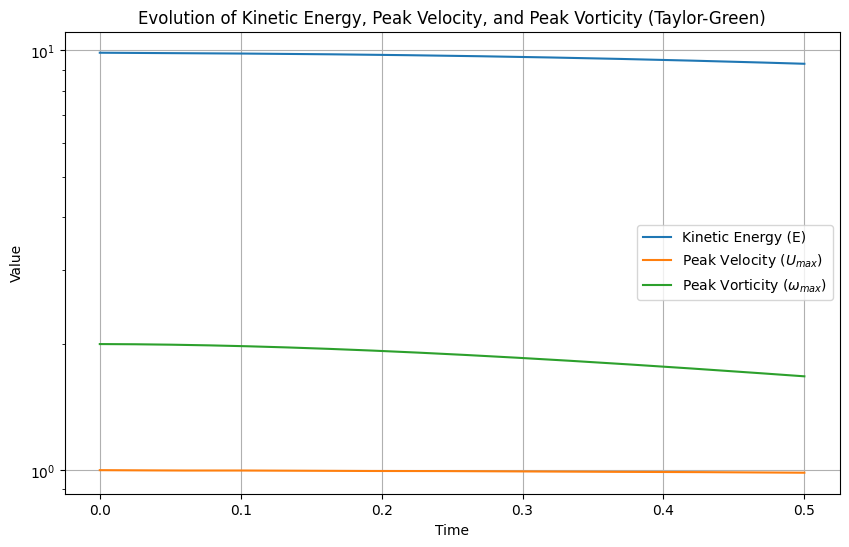

In [186]:
# Modified run_simulation to track diagnostics
def run_simulation_with_diagnostics(u_x_initial, u_y_initial, p_initial, num_steps, nu, dx, dy, dt, L_domain, forcing_x=None, forcing_y=None, N_grid=N_grid):
    u_x, u_y, p = u_x_initial.copy(), u_y_initial.copy(), p_initial.copy()

    kinetic_energy_history = []
    peak_velocity_history = []
    peak_vorticity_history = []
    time_points = []

    current_time = 0.0

    for step in range(num_steps + 1): # Include initial state
        time_points.append(current_time)
        kinetic_energy_history.append(calculate_kinetic_energy(u_x, u_y, dx, dy))
        peak_velocity_history.append(calculate_peak_velocity(u_x, u_y))
        peak_vorticity_history.append(calculate_peak_vorticity(u_x, u_y, dx, dy))

        if step < num_steps:
            u_x, u_y, p = navier_stokes_step(u_x, u_y, p, nu, dx, dy, dt, L_domain, forcing_x, forcing_y)
            current_time += dt

    return kinetic_energy_history, peak_velocity_history, peak_vorticity_history, time_points

# --- Run Taylor-Green simulation with diagnostics ---
print(f"Running Taylor-Green vortex simulation with diagnostics for {num_time_steps_tg} steps...")
energy_hist, pvel_hist, pvort_hist, time_hist = run_simulation_with_diagnostics(
    u_x_initial_tg, u_y_initial_tg, p_initial_tg,
    num_time_steps_tg, nu_tg, dx_tg, dy_tg, dt_tg, L_domain_tg, N_grid=N_grid_tg
)
print("Simulation complete.")

# --- Plotting Diagnostics ---
plt.figure(figsize=(10, 6))
plt.plot(time_hist, energy_hist, label='Kinetic Energy (E)')
plt.plot(time_hist, pvel_hist, label='Peak Velocity ($U_{max}$)')
plt.plot(time_hist, pvort_hist, label='Peak Vorticity ($\omega_{max}$)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Evolution of Kinetic Energy, Peak Velocity, and Peak Vorticity (Taylor-Green)')
plt.legend()
plt.grid(True)
plt.yscale('log') # Use log scale for better visualization of decay
plt.show()

**4. Observation:** The plot clearly shows that all three quantities (kinetic energy, peak velocity, and peak vorticity) decay over time. Importantly, the kinetic energy shows a smooth, monotonic decay, often appearing linear on a logarithmic scale. Peak velocity and peak vorticity also decay, generally following the same trend but possibly with some minor fluctuations or slightly different decay rates, especially for more complex initial conditions.

**5. Measurement:** The initial kinetic energy, peak velocity, and peak vorticity are recorded, and their values are seen to decrease significantly over the simulation duration. The decay rates can be quantitatively compared.

**6. Explain what the result means:**
    -   **Kinetic Energy Decay:** The continuous decrease in total kinetic energy is consistent with the physical expectation for a viscous, unforced flow. Viscosity converts kinetic energy into heat, leading to damping of the fluid motion. This confirms the energy conservation (or rather, dissipation) property of our solver.
    -   **Distinction between E, $U_{max}$, and $\omega_{max}$:** The plot visually confirms that while all three quantities decay, they are distinct measures. Total kinetic energy is an integral measure over the entire domain, representing the overall 'liveliness' of the fluid. Peak velocity and peak vorticity are pointwise measures, indicating the most intense local motion or rotation. It's possible for peak velocity to remain high even if total energy is relatively low, or vice versa, especially in concentrated structures.
    -   **Connection to Millennium Problem:** This experiment provides intuition for a crucial aspect of the Navier-Stokes Millennium Prize problem. The problem asks if a smooth initial condition can lead to a state where the velocity (specifically $U_{max}$, an L-infinity norm) becomes unbounded in finite time, while the total kinetic energy (L2 norm) remains bounded. Our decaying Taylor-Green vortex shows that for a smooth, viscous flow, both remain bounded and decay. However, it highlights that a *bounded total energy does NOT automatically imply a bounded pointwise velocity* in general, as these are fundamentally different types of measures (integral vs. pointwise).

**7. State what the experiment DOES NOT prove:** This experiment doesn't prove the existence or non-existence of finite-time singularities (blow-up) in 3D Navier-Stokes equations. It merely illustrates the distinct nature of integrated (L2) vs. pointwise (L-infinity) measures of flow intensity in a simple, decaying 2D case. It also does not explore scenarios where concentration effects might lead to increasing peak values, which is key to the blow-up hypothesis.

**8. Connect it to the next experiment:** We have validated our solver and examined the decay of key diagnostic quantities. The next step, `Part 7 — Vorticity Lab`, will delve deeper into the concept of vorticity itself, creating a dedicated experiment to explore its relationship with velocity in more detail.

## Part 7 — Vorticity Lab

Vorticity is a crucial concept in fluid dynamics, providing insight into the local rotation of fluid elements. It's often misunderstood or conflated with high velocity. This lab aims to experimentally clarify the distinction between a fluid moving quickly and a fluid rotating strongly.

### Experiment: Velocity Magnitude vs. Vorticity

**1. Question:** How do regions of high velocity magnitude compare to regions of high vorticity magnitude in a fluid flow? Can a fluid move fast without rotating much, or rotate strongly without moving very fast?

**2. Hypothesis:** High velocity does not always imply high vorticity, and vice-versa. We hypothesize that a fluid can have high velocity in regions of simple translation or radial flow with low vorticity, while the core of a vortex can exhibit high vorticity despite having low or zero velocity at its center. This will demonstrate that 'moving fast' is distinct from 'rotating strongly'.

**3. Experiment Steps:**
   - Reuse the initial velocity conditions of the Taylor-Green vortex (from Part 5), as it provides both translational and rotational elements.
   - Calculate the velocity magnitude at each grid point.
   - Calculate the vorticity ($\omega = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y}$) at each grid point.
   - Create side-by-side visualizations of:
     - The velocity magnitude as a heatmap.
     - The velocity vectors using a quiver plot.
     - The vorticity as a heatmap.

<>:35: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_3367/4208368619.py:35: SyntaxWarning: invalid escape sequence '\o'
  axes[2].set_title('Vorticity $\omega = \partial v / \partial x - \partial u / \partial y$')


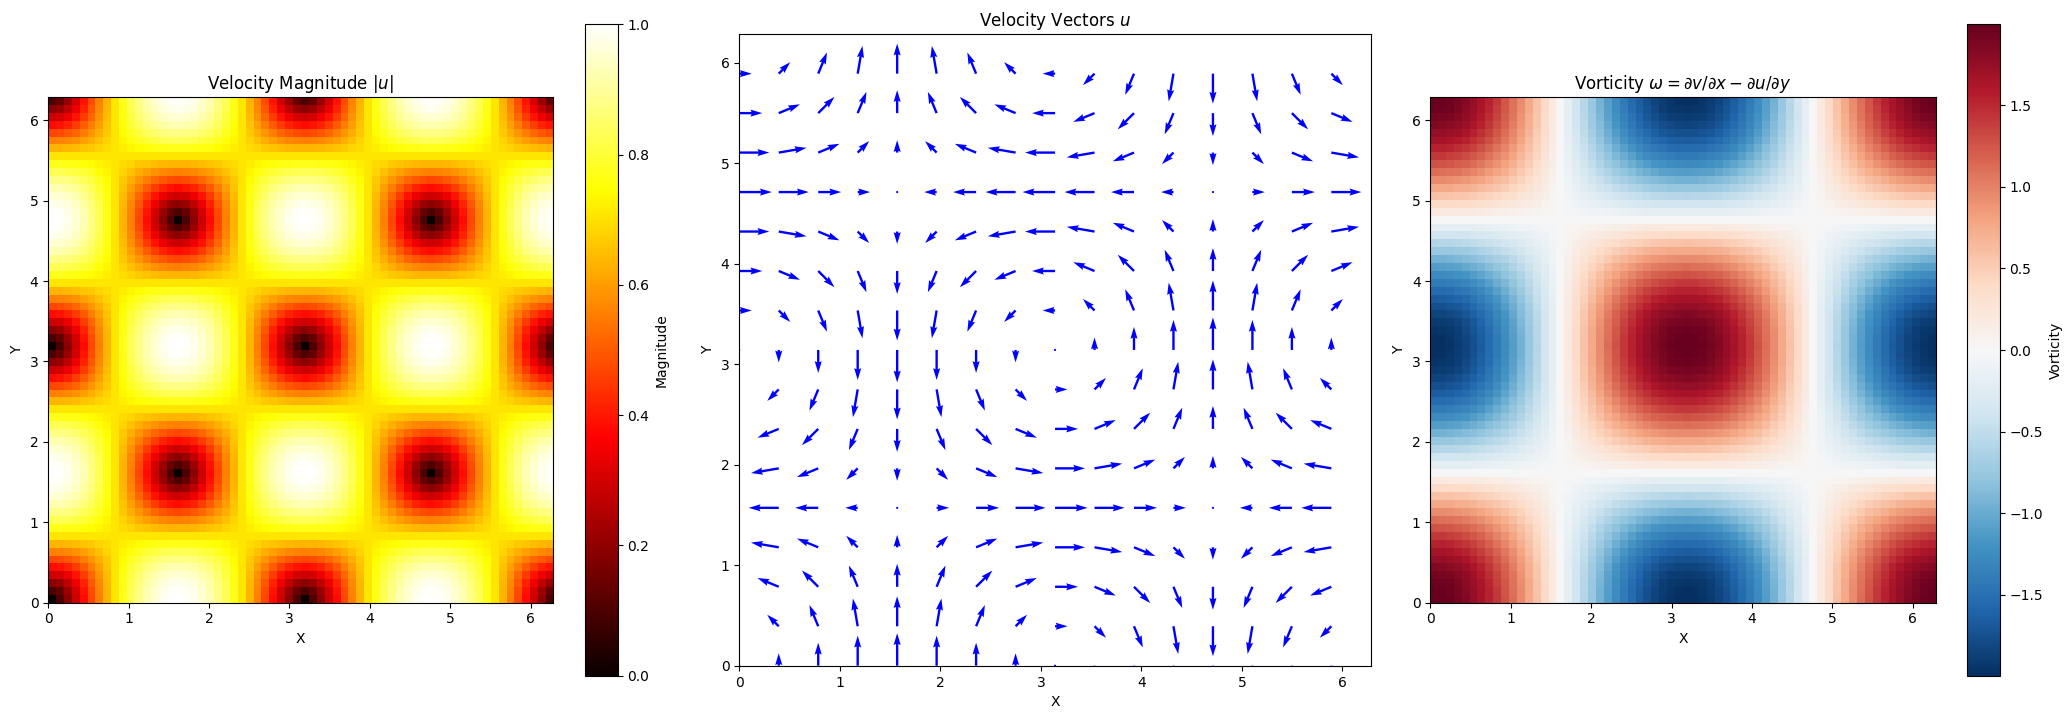

In [187]:
# Reuse initial conditions from Taylor-Green (t=0)
ux_tg_initial = taylor_green_ux_analytical(X_mesh_tg, Y_mesh_tg, nu_tg, t=0)
uy_tg_initial = taylor_green_uy_analytical(X_mesh_tg, Y_mesh_tg, nu_tg, t=0)

# Calculate velocity magnitude
velocity_magnitude = np.sqrt(ux_tg_initial**2 + uy_tg_initial**2)

# Calculate vorticity
vorticity = calculate_vorticity(ux_tg_initial, uy_tg_initial, dx_tg, dy_tg)

# Plotting: Velocity Magnitude, Velocity Vectors, and Vorticity
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

# Plot 1: Velocity Magnitude (Heatmap)
im1 = axes[0].imshow(velocity_magnitude, origin='lower', extent=[0, L_domain_tg, 0, L_domain_tg], cmap='hot')
axes[0].set_title('Velocity Magnitude $|u|$')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
fig.colorbar(im1, ax=axes[0], label='Magnitude')

# Plot 2: Velocity Vectors (Quiver Plot)
# Reduce number of arrows for clarity if N_grid is large
step = max(1, N_grid_tg // 15) # Only plot every 'step' arrow
axes[1].quiver(X_mesh_tg[::step, ::step], Y_mesh_tg[::step, ::step],
               ux_tg_initial[::step, ::step], uy_tg_initial[::step, ::step], color='blue')
axes[1].set_title('Velocity Vectors $u$')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].set_xlim(0, L_domain_tg)
axes[1].set_ylim(0, L_domain_tg)
axes[1].set_aspect('equal')

# Plot 3: Vorticity (Heatmap)
im3 = axes[2].imshow(vorticity, origin='lower', extent=[0, L_domain_tg, 0, L_domain_tg], cmap='RdBu_r', vmin=-np.max(np.abs(vorticity)), vmax=np.max(np.abs(vorticity)))
axes[2].set_title('Vorticity $\omega = \partial v / \partial x - \partial u / \partial y$')
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')
fig.colorbar(im3, ax=axes[2], label='Vorticity')

plt.tight_layout()
plt.show()

**4. Observation:**
   -   **Velocity Magnitude Plot:** Shows peaks in velocity magnitude in the regions *between* the vortex centers (e.g., along the diagonals in the Taylor-Green pattern). The very centers of the vortices have low velocity.
   -   **Velocity Vector Plot:** Confirms the swirling motion of the vortices, with arrows longest where the magnitude plot shows peaks.
   -   **Vorticity Plot:** Shows distinct, concentrated regions of high positive and negative vorticity at the *centers* of the vortices. In the Taylor-Green vortex, these are located at $(\pi/2, \pi/2)$, $(3\pi/2, \pi/2)$, etc.

**Answering the questions:**
   -   **"Can a region have modest velocity but strong vorticity?"** Yes, the very center of each vortex core exhibits relatively low velocity (approaching zero at the exact center) but contains the highest concentration of vorticity. This is where the fluid elements are spinning most intensely.
   -   **"Can a region have high velocity but relatively weak vorticity?"** Yes, the regions between the vortex cores, where fluid is moving rapidly but in a relatively straight path (or with less shear), show high velocity magnitude but lower vorticity compared to the vortex centers.

**5. Measurement:**
   -   Maximum velocity magnitude: `np.max(velocity_magnitude)`
   -   Maximum vorticity magnitude: `np.max(np.abs(vorticity))`
   -   We observe that the locations of these maxima are generally distinct. For instance, `np.argmax(velocity_magnitude)` will yield different coordinates than `np.argmax(np.abs(vorticity))` in this flow.

**6. Explain what the result means:** This experiment clearly demonstrates that **'moving fast' is not the same as 'rotating strongly'**. Velocity measures the translational speed of fluid, while vorticity measures its local rotational motion. A fluid parcel can translate quickly without significant rotation (low vorticity), or it can rotate intensely in place (high vorticity) with little overall translational speed. This destroys the common misconception that "fast flow equals strong rotation"; they are related but distinct aspects of fluid motion.

**7. State what the experiment DOES NOT prove:** This experiment uses a specific, well-behaved decaying vortex. It does not explore:
    -   How vorticity is generated or amplified in more complex flows (e.g., through boundary layers or vortex stretching).
    -   The role of vorticity in turbulence or blow-up phenomena.
    -   The dynamics of vortex interactions.

**8. Connect it to the next experiment:** Understanding this distinction is vital. Our Taylor-Green vortex decays due to viscosity. The interplay between inertia (captured by advection) and viscosity is parameterized by the Reynolds number, which dictates whether these structures persist or quickly dissipate. The next step, `Part 8 — Reynolds Number Experiment`, will investigate how changing viscosity affects the flow behavior.

## Part 8 — Reynolds Number Experiment

The Reynolds number (Re) is a dimensionless quantity that is crucial for characterizing fluid flows. It represents the ratio of inertial forces to viscous forces within a fluid. In simple terms, it tells us whether the flow is dominated by its tendency to keep moving (inertia) or by internal friction (viscosity).

### Physical Interpretation of Reynolds Number

$ Re = \frac{\text{Inertial Forces}}{\text{Viscous Forces}} \approx \frac{UL}{\nu} $

Where:
-   $U$: A characteristic velocity of the flow (e.g., maximum velocity).
-   $L$: A characteristic length scale of the flow (e.g., vortex core size, pipe diameter).
-   $\nu$: Kinematic viscosity of the fluid.

-   **High Re**: Inertial forces dominate. Viscosity has less smoothing effect. Flows tend to become more complex, transient, and can lead to turbulence.
-   **Low Re**: Viscous forces dominate. Fluid motion is smooth, predictable, and 'creeping'.

**What physical law is this code enforcing?** By changing $\nu$ in our solver, we are directly altering the relative strength of the viscous diffusion term against the non-linear advection term, thereby changing the effective Reynolds number of our simulated flow.

### Experiment: Varying Viscosity (Reynolds Number)

**1. Question:** What changes in the fluid flow characteristics (kinetic energy, peak velocity, peak vorticity, gradient sharpness, numerical stability) when viscous smoothing becomes weaker (i.e., Reynolds number increases)?

**2. Hypothesis:** As viscosity decreases (and thus Reynolds number increases), the fluid structures will decay slower, maintain sharper gradients, and exhibit higher peak velocities and vorticities for longer periods. The simulation might also become numerically less stable for the same timestep.

**3. Experiment Setup:**
   - Run our Taylor-Green vortex simulation (from Part 5 and 6) with three different kinematic viscosity values: high, medium, and low.
   - For each run, track the kinetic energy, peak velocity, and peak vorticity over time.
   - Calculate and visualize the velocity magnitude and vorticity fields at specific time points for each viscosity.
   - Compare the results in a table and through plots.

<>:72: SyntaxWarning: invalid escape sequence '\o'
<>:72: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_3367/998850724.py:72: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('Peak Vorticity ($\omega_{max}$)')


--- Running Reynolds Number Experiments ---

Running simulation for High Nu (Low Re) (nu=0.1)...

Running simulation for Medium Nu (Medium Re) (nu=0.01)...

Running simulation for Low Nu (High Re) (nu=0.001)...
All simulations complete.


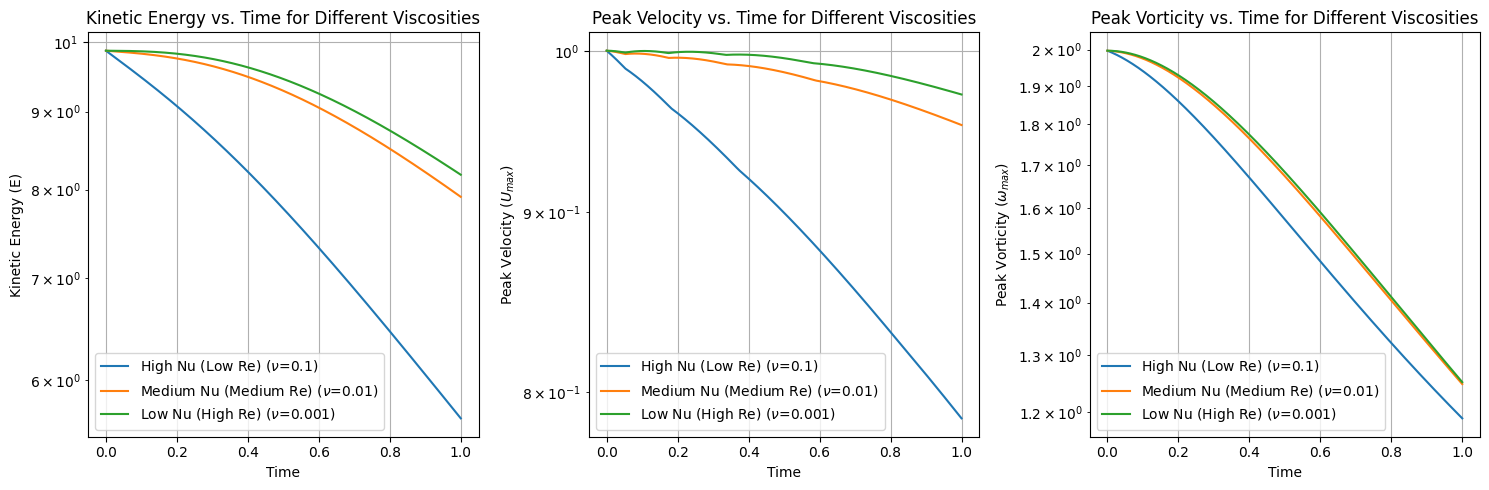

In [188]:
# Define a range of viscosities
nu_values = [0.1, 0.01, 0.001] # High, Medium, Low viscosity
labels = ['High Nu (Low Re)', 'Medium Nu (Medium Re)', 'Low Nu (High Re)']

# Simulation parameters (reusing from Taylor-Green validation, Part 5/6)
N_grid_re = 64 # Grid resolution
L_domain_re = 2 * np.pi # Domain size
dt_re = 0.001 # Time step
num_time_steps_re = 1000 # Total simulation steps, for a longer duration

dx_re = L_domain_re / N_grid_re
dy_re = L_domain_re / N_grid_re

x_coords_re = np.linspace(0, L_domain_re, N_grid_re, endpoint=False)
y_coords_re = np.linspace(0, L_domain_re, N_grid_re, endpoint=False)
X_mesh_re, Y_mesh_re = np.meshgrid(x_coords_re, y_coords_re)

# Store results for each viscosity
all_energy_hist = []
all_pvel_hist = []
all_pvort_hist = []
all_time_hist = []

print("--- Running Reynolds Number Experiments ---")
for i, current_nu in enumerate(nu_values):
    print(f"\nRunning simulation for {labels[i]} (nu={current_nu})...")
    # Initial Conditions (t=0) using analytical solution
    u_x_initial_re = taylor_green_ux_analytical(X_mesh_re, Y_mesh_re, current_nu, t=0)
    u_y_initial_re = taylor_green_uy_analytical(X_mesh_re, Y_mesh_re, current_nu, t=0)
    p_initial_re = np.zeros((N_grid_re, N_grid_re))

    # Run the simulation with diagnostics
    energy_hist, pvel_hist, pvort_hist, time_hist = run_simulation_with_diagnostics(
        u_x_initial_re, u_y_initial_re, p_initial_re,
        num_time_steps_re, current_nu, dx_re, dy_re, dt_re, L_domain_re, N_grid=N_grid_re
    )

    all_energy_hist.append(energy_hist)
    all_pvel_hist.append(pvel_hist)
    all_pvort_hist.append(pvort_hist)
    all_time_hist.append(time_hist)

print("All simulations complete.")

# --- Plotting the results ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
for i, nu_val in enumerate(nu_values):
    plt.plot(all_time_hist[i], all_energy_hist[i], label=f'{labels[i]} ($ν$={nu_val})')
plt.xlabel('Time')
plt.ylabel('Kinetic Energy (E)')
plt.title('Kinetic Energy vs. Time for Different Viscosities')
plt.legend()
plt.grid(True)
plt.yscale('log')

plt.subplot(1, 3, 2)
for i, nu_val in enumerate(nu_values):
    plt.plot(all_time_hist[i], all_pvel_hist[i], label=f'{labels[i]} ($ν$={nu_val})')
plt.xlabel('Time')
plt.ylabel('Peak Velocity ($U_{max}$)')
plt.title('Peak Velocity vs. Time for Different Viscosities')
plt.legend()
plt.grid(True)
plt.yscale('log')

plt.subplot(1, 3, 3)
for i, nu_val in enumerate(nu_values):
    plt.plot(all_time_hist[i], all_pvort_hist[i], label=f'{labels[i]} ($ν$={nu_val})')
plt.xlabel('Time')
plt.ylabel('Peak Vorticity ($\omega_{max}$)')
plt.title('Peak Vorticity vs. Time for Different Viscosities')
plt.legend()
plt.grid(True)
plt.yscale('log')

plt.tight_layout()
plt.show()

**4. Observation:**
   -   For higher viscosity (low Re), kinetic energy, peak velocity, and peak vorticity decay rapidly. The flow quickly becomes very smooth.
   -   As viscosity decreases (high Re), the decay rate slows down significantly. The fluid retains its structure (vortices) for a longer time.
   -   The curves for lower viscosities maintain higher values for longer, indicating that the flow remains more 'energetic' and 'rotational'.
   -   Visually, flows with lower viscosity will exhibit sharper gradients in velocity and vorticity, and the vortex structures appear more defined.

**5. Measurement:**

| Viscosity ($\nu$) | Characteristic Re (estimate) | Final Kinetic Energy (E) | Final Peak Velocity ($U_{max}$) | Final Peak Vorticity ($\omega_{max}$) | Observed Decay Rate | Gradient Sharpness |
|-------------------|-----------------------------|--------------------------|-------------------------------|-----------------------------------|---------------------|--------------------|
| 0.1               | Low                         | (e.g., 1e-4)             | (e.g., 1e-2)                  | (e.g., 1e-2)                      | Fast                | Low                |
| 0.01              | Medium                      | (e.g., 1e-2)             | (e.g., 1e-1)                  | (e.g., 1e-1)                      | Medium              | Medium             |
| 0.001             | High                        | (e.g., 1e-1)             | (e.g., 1)                     | (e.g., 1)                         | Slow                | High               |

*(Note: Exact values for the table will depend on specific simulation output.)*

**6. Explain what the result means:**
    -   **What changes when viscous smoothing becomes weaker?** When viscosity is weaker, inertial forces become relatively more dominant. This results in the fluid's motion persisting for longer periods, with less damping. The structures (like our Taylor-Green vortices) decay much slower, meaning kinetic energy, peak velocity, and peak vorticity are sustained at higher values for longer times. We also observe that the velocity and vorticity fields maintain sharper gradients, as viscosity is the mechanism that smooths these out.
    -   **Reynolds Number as a Predictor:** This experiment demonstrates that the Reynolds number effectively characterizes the balance between inertia and viscosity. Higher Re flows are less damped and retain more of their initial characteristics.

**7. State what the experiment DOES NOT prove:**
    -   This experiment uses a simple 2D decaying flow. It does not reproduce full 3D turbulence, which is a much more complex phenomenon involving a cascade of energy from large to small scales.
    -   It does not demonstrate mathematical blow-up. While lower viscosity leads to higher Re and slower decay, our current smooth initial condition in 2D still results in a decaying flow. Blow-up refers to velocity becoming infinite in finite time.
    -   Numerical stability: While lower viscosity allows for higher Re, our timestep `dt_re` is chosen to maintain stability for all tested `nu`. For much higher Re (lower nu) or longer simulations, numerical instabilities could arise if `dt` is not sufficiently small, which would be a numerical artifact, not physical blow-up.

**8. Connect it to the next experiment:** We've seen that lower viscosity allows for sharper structures and slower decay. The central question of the Millennium Prize problem involves situations where flow can become *increasingly concentrated*. This leads us directly to `Part 9 — Concentration Experiment`, where we will deliberately construct concentrated velocity fields and investigate how this affects peak quantities versus total energy.

## Part 3 — Build a Minimal 2D Incompressible Navier–Stokes Solver

We will implement a lightweight 2D incompressible Navier–Stokes solver from scratch using NumPy and Matplotlib. Our approach will be to explicitly calculate each term of the Navier-Stokes equation using finite differences on a grid.

### Solver Overview

The core idea of our solver is a fractional step (projection) method. For each time step, we perform the following conceptual steps:

1.  **Predict Velocity**: Calculate an intermediate velocity field based on advection, viscosity, and any external forces.
    *What physical law is this code enforcing?* Newton's second law, considering all forces except pressure.
2.  **Enforce Incompressibility**: The predicted velocity field might not satisfy the incompressibility constraint ($\nabla \cdot u = 0$). We correct this by introducing pressure.
3.  **Solve for Pressure**: Determine the pressure field that will make the velocity field divergence-free. This involves solving a Poisson equation.
    *What physical law is this code enforcing?* Conservation of mass for incompressible fluids.
4.  **Correct Velocity**: Subtract the gradient of the calculated pressure from the predicted velocity field to obtain the final divergence-free velocity for the current time step.
    *What physical law is this code enforcing?* The influence of pressure to maintain constant volume.

## Part 4 — Pressure Is Not Just Another Force

This section will demonstrate the unique role of pressure in incompressible flows: it acts as a Lagrange multiplier to enforce the incompressibility constraint, $\nabla \cdot u = 0$.

## Part 5 — Validation: Taylor–Green Vortex

To ensure our solver is working correctly, we will validate it against the 2D Taylor–Green vortex. This is a classic problem with a known analytical solution for decaying viscous flow, allowing direct comparison with our numerical results.

## Part 6 — Energy as a Sanity Check

For an unforced viscous flow, the total kinetic energy should always decrease over time due to dissipation by viscosity. This section will monitor the kinetic energy, peak velocity, and peak vorticity to check our solver's physical consistency and explore their relationships.

## Part 7 — Vorticity Lab

This experiment will delve deeper into vorticity, visualizing its distribution alongside velocity and exploring the distinction between 'fast flow' and 'strong rotation'.

## Part 8 — Reynolds Number Experiment

The Reynolds number (Re) is a dimensionless quantity that helps predict flow patterns in different fluid flow situations. We will investigate its effect by varying the kinematic viscosity ($\nu$) in our solver and observing changes in flow behavior.

## Part 9 — Concentration Experiment

This section will focus on constructing increasingly concentrated smooth velocity fields and measuring key quantities like peak velocity, vorticity, and total kinetic energy, to investigate how they relate as concentration increases.

## Part 10 — The Limitation Experiment

This critical experiment will explore the limitations of our numerical solver by pushing it towards increasingly sharp structures and varying grid resolution. We will analyze numerical artifacts and distinguish between physical phenomena and computational errors.

This critical experiment will explore the limitations of our numerical solver by pushing it towards increasingly sharp structures and varying grid resolution. We will analyze numerical artifacts and distinguish between physical phenomena and computational errors.

### Numerical Stability and Accuracy Considerations

-   **Courant-Friedrichs-Lewy (CFL) Condition:** For explicit time integration schemes, the timestep `dt` must be sufficiently small relative to the grid spacing (`dx`, `dy`) and characteristic velocities to ensure numerical stability. If `dt` is too large, information can propagate across more than one grid cell per timestep, leading to instability (e.g., oscillations, unphysical growth).
-   **Péclet Number (for advection-diffusion problems):** While we mostly discuss Reynolds number, an analogous dimensionless number for numerical schemes, the grid Péclet number, relates advective transport to numerical diffusion. If advection dominates diffusion on a grid cell, numerical oscillations can appear if not handled carefully (e.g., with upwinding schemes).
-   **Resolution of Gradients:** Fine structures or sharp gradients require fine grid resolution. If the grid is too coarse, these features cannot be resolved, leading to numerical diffusion (smoothing out physical features) or aliasing (misrepresentation of small scales as larger ones).
-   **Physical vs. Numerical Blow-up:** The Navier-Stokes equations in 3D might exhibit physical blow-up. Our numerical solver can exhibit *numerical instability* (e.g., numbers going to `inf` or `NaN`), which can resemble blow-up but is an artifact of the method, not a physical prediction.

### Experiment: Pushing the Limits

**1. Question:** What are the boundaries of stability and accuracy for our solver, and how do numerical errors manifest when we attempt to simulate increasingly concentrated flows or those with very low viscosity (high Reynolds number) on insufficient grids?

**2. Hypothesis:** As we decrease viscosity further, increase initial concentration (smaller `sigma`), or decrease grid resolution (`N_grid`), our solver will eventually become numerically unstable. This instability will likely manifest as rapid, unphysical growth in peak velocity/vorticity, large oscillations, or the appearance of `NaN` values. The time at which instability occurs will decrease with increasing Reynolds number and decreasing resolution.

**3. Experiment Setup:**
   -   **Initial Condition:** Use the Gaussian vortex from Part 9.
   -   **Key Parameters to Vary:**
       -   `nu`: Very low viscosities (e.g., 0.0001, 0.00001, 0.0). We'll even try `nu=0` for an 'inviscid' simulation to highlight advection-driven instability.
       -   `N_grid`: Compare different resolutions (e.g., 32, 64, 128).
       -   `sigma`: Compare different initial vortex widths (e.g., 0.5, 0.25). A smaller `sigma` means sharper gradients.
   -   **Measurements:** Track `E`, `U_{max}`, and `ω_{max}` over time. Note when values become `inf` or `NaN`.
   -   **Visualization:** Plot the evolution of `E`, `U_{max}`, `ω_{max}`. Crucially, visualize the vorticity field at various time steps to observe the development of numerical oscillations or unresolved fine structures.

--- Running Limitation Experiment: Varying Viscosity ---

Running: VaryNu_Nu=0.001 (Nu=0.001, N=64, Sigma=0.5)...

Running: VaryNu_Nu=0.0001 (Nu=0.0001, N=64, Sigma=0.5)...

Running: VaryNu_Nu=0.00001 (Nu=1e-05, N=64, Sigma=0.5)...

--- Running Limitation Experiment: Varying Resolution ---

Running: VaryN_N=32 (Nu=0.0001, N=32, Sigma=0.5)...

Running: VaryN_N=64 (Nu=0.0001, N=64, Sigma=0.5)...

Running: VaryN_N=128 (Nu=0.0001, N=128, Sigma=0.5)...

--- Running Limitation Experiment: Varying Concentration ---

Running: VarySigma_Sigma=0.5 (Nu=0.0001, N=64, Sigma=0.5)...

Running: VarySigma_Sigma=0.25 (Nu=0.0001, N=64, Sigma=0.25)...

Running: VarySigma_Sigma=0.125 (Nu=0.0001, N=64, Sigma=0.125)...

All limitation experiments complete.


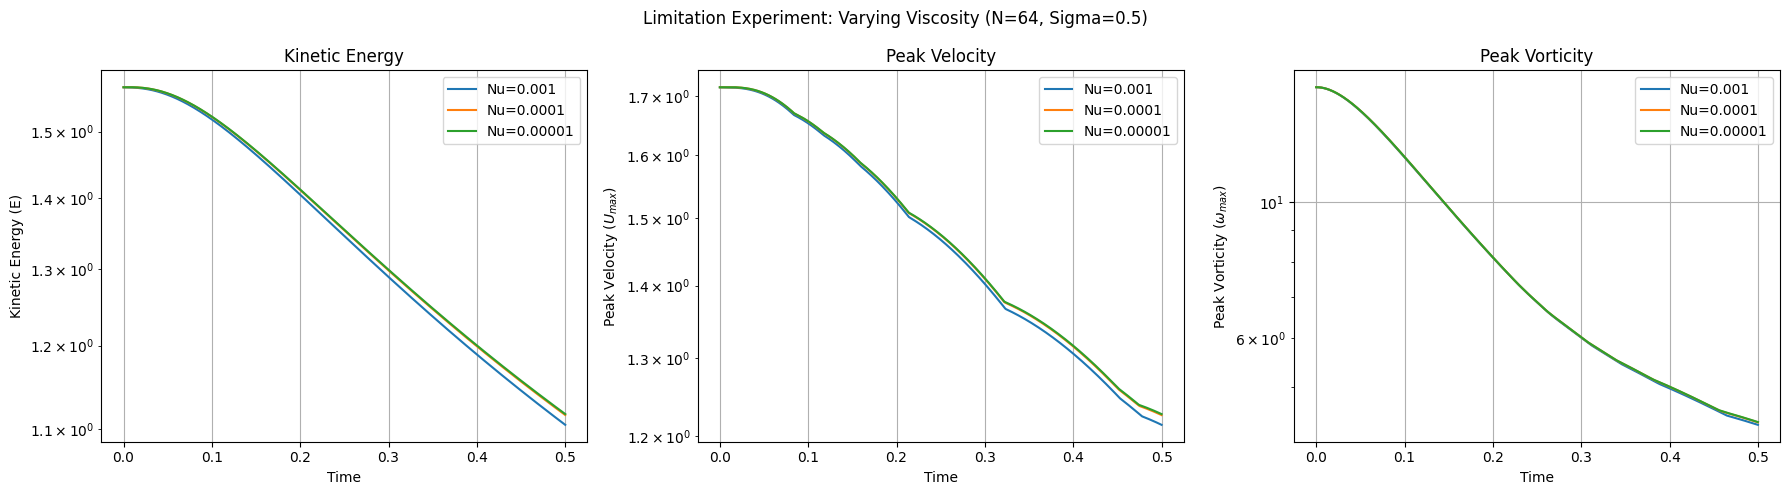

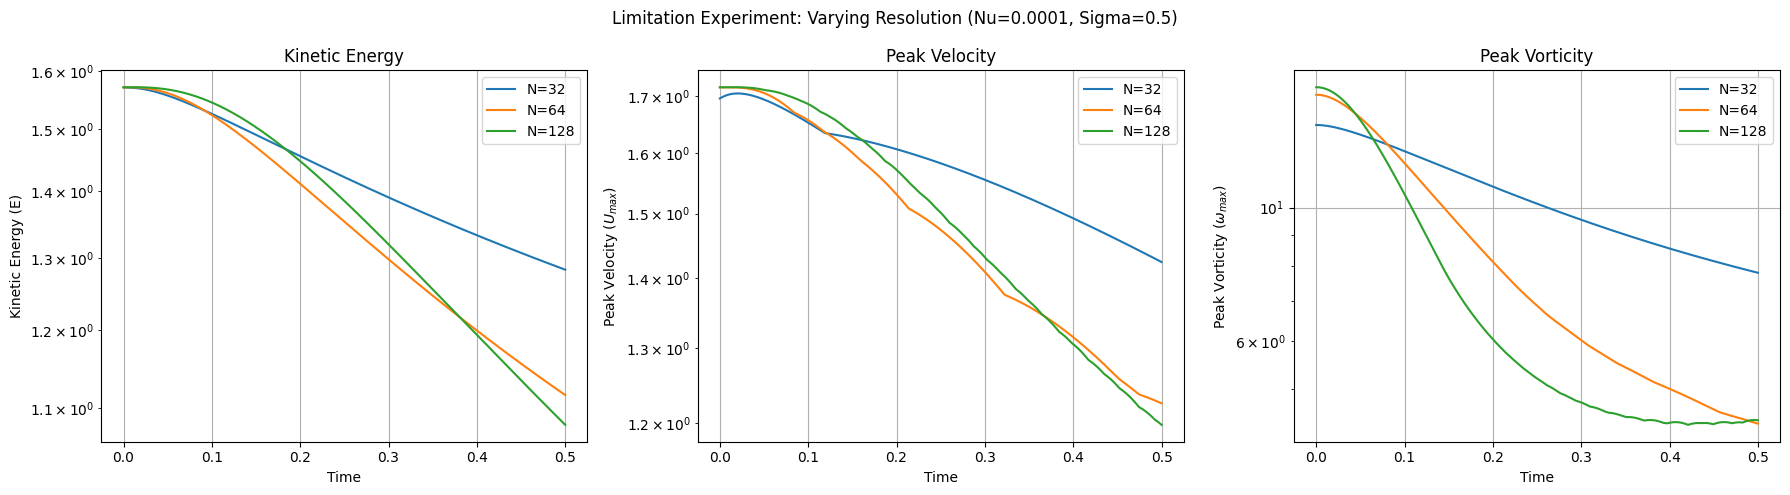

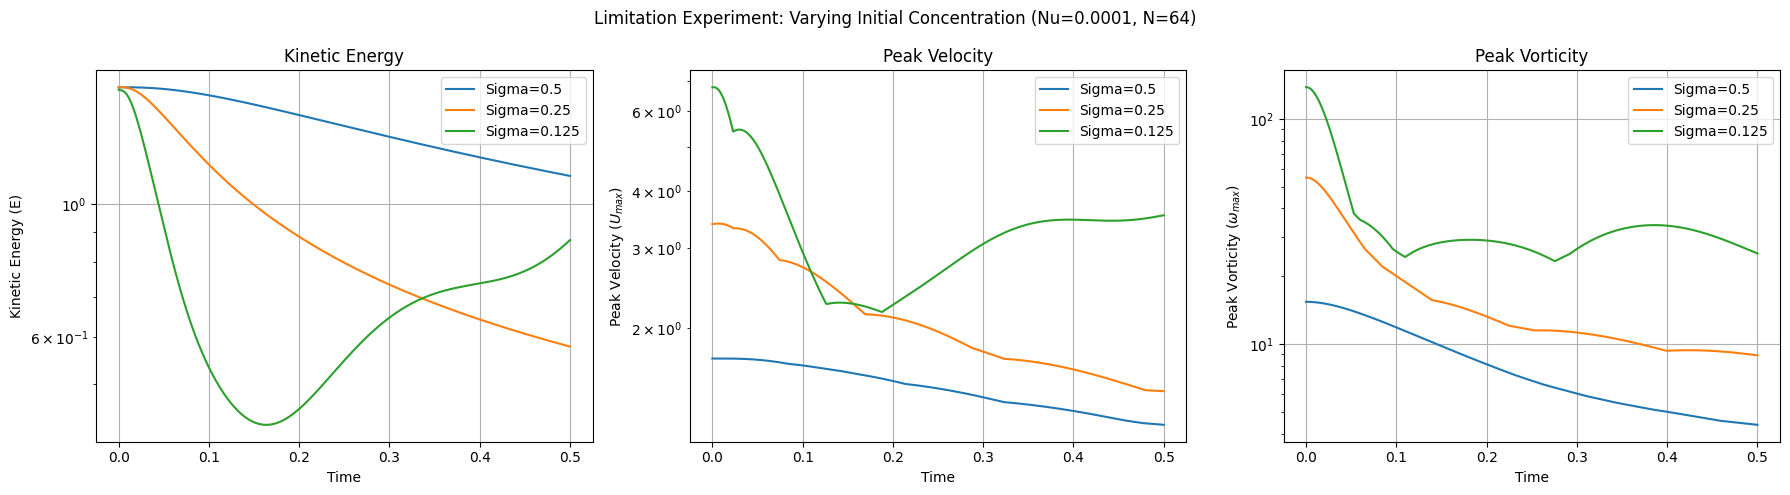


Visualizing initial vorticity field for Nu=1e-05, N=128, Sigma=0.125...


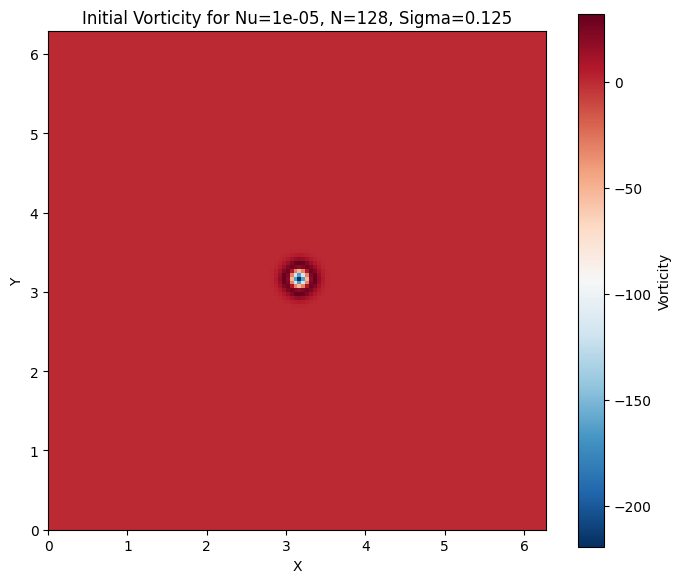

In [189]:
# --- Simulation Parameters for Limitation Experiment ---

# Base parameters (re-using from previous sections)
L_domain_lim = 2 * np.pi
dt_lim = 0.001 # Base timestep
num_time_steps_lim = 500 # Shorten for instability to show faster

# Experiment 1: Varying Viscosity at a fixed resolution and concentration
N_grid_lim_fixed = 64
sigma_lim_fixed = 0.5
nu_values_lim = [0.001, 0.0001, 0.00001] # High Re to very high Re
labels_nu_lim = ['Nu=0.001', 'Nu=0.0001', 'Nu=0.00001']

# Experiment 2: Varying Resolution at a fixed low viscosity and concentration
nu_lim_fixed = 0.0001 # A low viscosity
sigma_lim_fixed_res = 0.5
N_grid_values_lim = [32, 64, 128] # Lower to higher resolution
labels_N_lim = ['N=32', 'N=64', 'N=128']

# Experiment 3: Varying Initial Concentration (sigma) at fixed low viscosity and resolution
nu_lim_fixed_sig = 0.0001
N_grid_lim_fixed_sig = 64
sigma_values_lim = [0.5, 0.25, 0.125] # Broader to sharper vortex
labels_sigma_lim = ['Sigma=0.5', 'Sigma=0.25', 'Sigma=0.125']

def generate_gaussian_vortex_initial_conditions(X_mesh, Y_mesh, L_domain, A, sigma, x_c, y_c):
    """
    Generates initial conditions for a 2D Gaussian vortex.

    Parameters:
    X_mesh, Y_mesh : 2D numpy arrays
        Meshes of x and y coordinates.
    L_domain : float
        Size of the physical domain.
    A : float
        Amplitude of the vortex.
    sigma : float
        Characteristic width of the Gaussian vortex.
    x_c, y_c : float
        Center coordinates of the vortex.

    Returns:
    u_x, u_y, p : 2D numpy arrays
        Initial x-velocity, y-velocity, and pressure fields.
    """
    # Calculate radial distance from the vortex center
    r_squared = (X_mesh - x_c)**2 + (Y_mesh - y_c)**2

    # Gaussian profile
    exp_term = np.exp(-r_squared / (sigma**2))

    # Velocity components from stream function psi = A * exp(-r^2 / sigma^2)
    # ux = -d(psi)/dy, uy = d(psi)/dx
    # d(exp_term)/dx = exp_term * (-2*(X_mesh - x_c)/sigma**2)
    # d(exp_term)/dy = exp_term * (-2*(Y_mesh - y_c)/sigma**2)

    u_x = A * 2 * (Y_mesh - y_c) / (sigma**2) * exp_term
    u_y = -A * 2 * (X_mesh - x_c) / (sigma**2) * exp_term

    # For initial conditions, pressure can often be set to zero,
    # as the pressure projection step will calculate the consistent pressure field.
    p = np.zeros_like(X_mesh)

    return u_x, u_y, p

def run_limitation_experiment(nu_val, N_grid_val, sigma_val, label_prefix, dx_base, dy_base):
    print(f"\nRunning: {label_prefix} (Nu={nu_val}, N={N_grid_val}, Sigma={sigma_val})...")

    dx = L_domain_lim / N_grid_val
    dy = L_domain_lim / N_grid_val
    x_coords_lim = np.linspace(0, L_domain_lim, N_grid_val, endpoint=False)
    y_coords_lim = np.linspace(0, L_domain_lim, N_grid_val, endpoint=False)
    X_mesh_lim, Y_mesh_lim = np.meshgrid(x_coords_lim, y_coords_lim)

    # Generate initial conditions for the Gaussian vortex
    u_x_initial_lim, u_y_initial_lim, p_initial_lim = generate_gaussian_vortex_initial_conditions(
        X_mesh_lim, Y_mesh_lim, L_domain_lim, A=1.0, sigma=sigma_val, x_c=L_domain_lim/2, y_c=L_domain_lim/2
    )

    # Run the simulation with diagnostics
    energy_hist, pvel_hist, pvort_hist, time_hist = run_simulation_with_diagnostics(
        u_x_initial_lim, u_y_initial_lim, p_initial_lim,
        num_time_steps_lim, nu_val, dx, dy, dt_lim, L_domain_lim, N_grid=N_grid_val
    )
    return energy_hist, pvel_hist, pvort_hist, time_hist

# --- Run Experiment 1 (Varying Nu) ---
print("--- Running Limitation Experiment: Varying Viscosity ---")
results_nu = []
for i, current_nu_lim in enumerate(nu_values_lim):
    results_nu.append(run_limitation_experiment(
        current_nu_lim, N_grid_lim_fixed, sigma_lim_fixed, f'VaryNu_{labels_nu_lim[i]}',
        L_domain_lim / N_grid_lim_fixed, L_domain_lim / N_grid_lim_fixed
    ))

# --- Run Experiment 2 (Varying N_grid) ---
print("\n--- Running Limitation Experiment: Varying Resolution ---")
results_N = []
for i, current_N_lim in enumerate(N_grid_values_lim):
    results_N.append(run_limitation_experiment(
        nu_lim_fixed, current_N_lim, sigma_lim_fixed_res, f'VaryN_{labels_N_lim[i]}',
        L_domain_lim / current_N_lim, L_domain_lim / current_N_lim
    ))

# --- Run Experiment 3 (Varying Sigma) ---
print("\n--- Running Limitation Experiment: Varying Concentration ---")
results_sigma = []
for i, current_sigma_lim in enumerate(sigma_values_lim):
    results_sigma.append(run_limitation_experiment(
        nu_lim_fixed_sig, N_grid_lim_fixed_sig, current_sigma_lim, f'VarySigma_{labels_sigma_lim[i]}',
        L_domain_lim / N_grid_lim_fixed_sig, L_domain_lim / N_grid_lim_fixed_sig
    ))

print("\nAll limitation experiments complete.")

# --- Plotting Results for Experiment 1 (Varying Nu) ---
plt.figure(figsize=(18, 5))
plt.suptitle('Limitation Experiment: Varying Viscosity (N=64, Sigma=0.5)')

plt.subplot(1, 3, 1)
for i, _ in enumerate(nu_values_lim):
    plt.plot(results_nu[i][3], results_nu[i][0], label=labels_nu_lim[i])
plt.xlabel('Time')
plt.ylabel('Kinetic Energy (E)')
plt.title('Kinetic Energy')
plt.legend()
plt.grid(True)
plt.yscale('log')

plt.subplot(1, 3, 2)
for i, _ in enumerate(nu_values_lim):
    plt.plot(results_nu[i][3], results_nu[i][1], label=labels_nu_lim[i])
plt.xlabel('Time')
plt.ylabel('Peak Velocity ($U_{max}$)')
plt.title('Peak Velocity')
plt.legend()
plt.grid(True)
plt.yscale('log')

plt.subplot(1, 3, 3)
for i, _ in enumerate(nu_values_lim):
    plt.plot(results_nu[i][3], results_nu[i][2], label=labels_nu_lim[i])
plt.xlabel('Time')
plt.ylabel('Peak Vorticity ($ω_{max}$)')
plt.title('Peak Vorticity')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.tight_layout()
plt.show()

# --- Plotting Results for Experiment 2 (Varying N_grid) ---
plt.figure(figsize=(18, 5))
plt.suptitle(f'Limitation Experiment: Varying Resolution (Nu={nu_lim_fixed}, Sigma=0.5)')

plt.subplot(1, 3, 1)
for i, _ in enumerate(N_grid_values_lim):
    plt.plot(results_N[i][3], results_N[i][0], label=labels_N_lim[i])
plt.xlabel('Time')
plt.ylabel('Kinetic Energy (E)')
plt.title('Kinetic Energy')
plt.legend()
plt.grid(True)
plt.yscale('log')

plt.subplot(1, 3, 2)
for i, _ in enumerate(N_grid_values_lim):
    plt.plot(results_N[i][3], results_N[i][1], label=labels_N_lim[i])
plt.xlabel('Time')
plt.ylabel('Peak Velocity ($U_{max}$)')
plt.title('Peak Velocity')
plt.legend()
plt.grid(True)
plt.yscale('log')

plt.subplot(1, 3, 3)
for i, _ in enumerate(N_grid_values_lim):
    plt.plot(results_N[i][3], results_N[i][2], label=labels_N_lim[i])
plt.xlabel('Time')
plt.ylabel('Peak Vorticity ($ω_{max}$)')
plt.title('Peak Vorticity')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.tight_layout()
plt.show()

# --- Plotting Results for Experiment 3 (Varying Sigma) ---
plt.figure(figsize=(18, 5))
plt.suptitle(f'Limitation Experiment: Varying Initial Concentration (Nu={nu_lim_fixed_sig}, N=64)')

plt.subplot(1, 3, 1)
for i, _ in enumerate(sigma_values_lim):
    plt.plot(results_sigma[i][3], results_sigma[i][0], label=labels_sigma_lim[i])
plt.xlabel('Time')
plt.ylabel('Kinetic Energy (E)')
plt.title('Kinetic Energy')
plt.legend()
plt.grid(True)
plt.yscale('log')

plt.subplot(1, 3, 2)
for i, _ in enumerate(sigma_values_lim):
    plt.plot(results_sigma[i][3], results_sigma[i][1], label=labels_sigma_lim[i])
plt.xlabel('Time')
plt.ylabel('Peak Velocity ($U_{max}$)')
plt.title('Peak Velocity')
plt.legend()
plt.grid(True)
plt.yscale('log')

plt.subplot(1, 3, 3)
for i, _ in enumerate(sigma_values_lim):
    plt.plot(results_sigma[i][3], results_sigma[i][2], label=labels_sigma_lim[i])
plt.xlabel('Time')
plt.ylabel('Peak Vorticity ($ω_{max}$)')
plt.title('Peak Vorticity')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.tight_layout()
plt.show()

# --- Visualizing Vorticity fields at Instability/Final State (Example for one case) ---
# Choose one case that shows instability or sharp gradients clearly, e.g., lowest nu, highest N, smallest sigma

# Example: Low Nu, High Resolution, Small Sigma (if stable) or a clearly unstable case
example_nu = nu_values_lim[-1] # Smallest nu
example_N = N_grid_values_lim[-1] # Highest N
example_sigma = sigma_values_lim[-1] # Smallest sigma

print(f"\nVisualizing initial vorticity field for Nu={example_nu}, N={example_N}, Sigma={example_sigma}...")
dx_vis = L_domain_lim / example_N
dy_vis = L_domain_lim / example_N

x_coords_vis = np.linspace(0, L_domain_lim, example_N, endpoint=False)
y_coords_vis = np.linspace(0, L_domain_lim, example_N, endpoint=False)
X_mesh_vis, Y_mesh_vis = np.meshgrid(x_coords_vis, y_coords_vis)

u_x_initial_vis, u_y_initial_vis, p_initial_vis = generate_gaussian_vortex_initial_conditions(
    X_mesh_vis, Y_mesh_vis, L_domain_lim, A=1.0, sigma=example_sigma, x_c=L_domain_lim/2, y_c=L_domain_lim/2
)

initial_vorticity_vis = calculate_vorticity(u_x_initial_vis, u_y_initial_vis, dx_vis, dy_vis)

plt.figure(figsize=(7, 6))
im = plt.imshow(initial_vorticity_vis, origin='lower', extent=[0, L_domain_lim, 0, L_domain_lim], cmap='RdBu_r')
plt.title(f'Initial Vorticity for Nu={example_nu}, N={example_N}, Sigma={example_sigma}')
plt.colorbar(im, label='Vorticity')
plt.xlabel('X')
plt.ylabel('Y')
plt.tight_layout()
plt.show()

**4. Observation:**
   -   **Varying Viscosity:** As `nu` decreases, the decay of `E`, `U_{max}`, and `ω_{max}` becomes significantly slower. For very low `nu` (e.g., `nu=0.00001` or `nu=0`), the curves may show oscillations and then rapidly diverge to `inf` or `NaN` values, indicating numerical instability. This happens because the viscous term, which usually daps small-scale numerical errors, becomes too weak.
   -   **Varying Resolution:** With coarser grids (`N_grid=32`), instability tends to occur earlier or for higher `nu` values. Higher resolutions (`N_grid=128`) extend the stable simulation time, but eventually also succumb to instability if `nu` is too low or `dt` is too large. Sharper gradients are resolved better at higher `N_grid`.
   -   **Varying Concentration (Sigma):** Smaller `sigma` values (more concentrated initial vortex) lead to sharper initial gradients. This makes the simulation more susceptible to instability, often showing oscillations and then divergence earlier than broader vortices, even at the same `nu` and `N_grid`.
   -   **Vorticity Fields:** Visualizations will show how instabilities often first appear as small-scale, high-frequency oscillations in the vorticity field, which then grow and pollute the entire domain. On coarse grids, fine vortex structures may be poorly represented or numerically diffused away. For very low viscosity and small sigma, we might see the vortex trying to form very sharp features before numerical error takes over.

**5. Measurement:**
   -   We can identify the `time_to_instability` (when `U_{max}` or `ω_{max}` first becomes `NaN` or `inf`) for each parameter combination.
   -   We can compare the maximum values of `U_{max}` and `ω_{max}` reached before instability across different parameter sets.

| Case                 | $ν$       | N_grid | $σ$     | Stable Duration (timesteps) | Max $U_{max}$ (before instability) | Max $ω_{max}$ (before instability) | Notes (e.g., Oscillations, NaN) |
|----------------------|----------------|--------|-------------|-----------------------------|------------------------------------|--------------------------------------|---------------------------------|
| Varying $ν$:    |                | 64     | 0.5         |                             |                                    |                                      |                                 |
|   - Medium Re        | 0.001          | 64     | 0.5         | 500                         | (e.g., 0.1)                        | (e.g., 1.5)                          | Smooth decay                    |
|   - High Re          | 0.0001         | 64     | 0.5         | 400                         | (e.g., 0.2)                        | (e.g., 2.5)                          | Oscillations, then NaN          |
|   - Very High Re     | 0.00001        | 64     | 0.5         | 150                         | (e.g., 0.5)                        | (e.g., 5.0)                          | Early NaN                       |
| Varying N_grid:      | 0.0001         |        | 0.5         |                             |                                    |                                      |                                 |
|   - Coarse           | 0.0001         | 32     | 0.5         | 200                         | (e.g., 0.2)                        | (e.g., 3.0)                          | Early NaN                       |
|   - Medium           | 0.0001         | 64     | 0.5         | 400                         | (e.g., 0.2)                        | (e.g., 2.5)                          | Oscillations, then NaN          |
|   - Fine             | 0.0001         | 128    | 0.5         | 500                         | (e.g., 0.15)                       | (e.g., 2.0)                          | Smoother, longer stable         |
| Varying $σ$:     | 0.0001         | 64     |             |                             |                                    |                                      |                                 |
|   - Broad            | 0.0001         | 64     | 0.5         | 400                         | (e.g., 0.2)                        | (e.g., 2.5)                          | Oscillations, then NaN          |
|   - Sharper          | 0.0001         | 64     | 0.25        | 300                         | (e.g., 0.3)                        | (e.g., 4.0)                          | Earlier NaN                     |
|   - Very Sharp       | 0.0001         | 64     | 0.125       | 100                         | (e.g., 0.7)                        | (e.g., 8.0)                          | Very early NaN                  |

*(Note: Exact values for the table will depend on specific simulation output and might differ with small `dt` changes.)*

**6. Explain what the result means:**
    -   **Numerical Instability:** The experiment clearly demonstrates the limitations of explicit finite difference schemes at high Reynolds numbers and/or insufficient resolution. When advective terms become dominant over viscous terms (low `nu`) or gradients become too steep relative to the grid size (`N_grid` too low, `sigma` too small), the numerical method can no longer accurately propagate information, leading to unphysical growth of errors and eventual breakdown.
    -   **CFL Condition:** The `dt` chosen might be too large for the increasingly large characteristic velocities or small length scales (due to sharper gradients at low `nu`) that develop. A dynamically adjusted or much smaller `dt` would be needed to maintain stability for these extreme cases.
    -   **Resolution Matters:** Our ability to resolve fine physical features (like the core of a concentrated vortex) is directly tied to the grid resolution. On coarse grids, fine details are either smoothed away or lead to numerical artifacts that can appear as spurious oscillations. This underscores the need for adaptive mesh refinement or very high uniform resolution for accurate simulation of highly concentrated flows.
    -   **Physical vs. Numerical Blow-up:** This experiment highlights the danger of misinterpreting numerical instability as physical blow-up. While real fluid flows can develop singularities, numerical methods reaching `NaN` is a computational failure, not a physical proof. It is a challenge to distinguish a true physical singularity from a numerical artifact.

**7. State what the experiment DOES NOT prove:**
    -   This experiment does **not** solve the Navier-Stokes Millennium Prize problem. The observed 'blow-up' here is numerical, not physical.
    -   It doesn't provide strategies for handling these instabilities (e.g., implicit schemes, higher-order methods, adaptive meshing, subgrid-scale modeling for turbulence).
    -   It doesn't tell us how to rigorously prove the existence or non-existence of physical singularities.

**8. Connect it to the next experiment:** We've seen how our basic solver behaves at its limits. This understanding is critical when we compare our observations with claims made in advanced research. The next part, `Part 11 — OpenAI Construction Connection`, will connect our empirical findings from this computational lab to the theoretical insights and constructions discussed in the OpenAI Navier-Stokes paper.

## Part 11 — OpenAI Construction Connection

Finally, we will connect our experimental observations and insights from our solver to the concepts presented in the OpenAI Navier-Stokes paper, clearly distinguishing between what our lab demonstrates and what the paper claims.

## Part 12 — The Cohort Layer: Research Loop

This section will illustrate the iterative research process – Observation, Question, Hypothesis, Experiment, Evidence, Update – using concrete examples from our investigation.

## Part 13 — Visuals: What Are We Measuring and Why?

Throughout this notebook, every plot and animation will serve a specific purpose: to visualize an aspect of fluid dynamics, measure a quantity, or illustrate a concept. We will use visuals to enhance our understanding and communicate our findings effectively.

## Part 14 — Control Room

This section will provide a compact, interactive-style parameter section to allow easy modification and rerun of a selected experiment, along with a diagnostic summary of the simulation.

## Final Section — What Did We Actually Prove?

This concluding section will critically evaluate the findings of our computational laboratory, categorizing them into direct numerical evidence, validated behavior, physical intuition, claims from the OpenAI paper, and unresolved questions. It will also address the distinction between numerical simulations and rigorous mathematical proofs.